# S004 — Ransomware Detection System
## Research-Grade ML Pipeline: Training, Evaluation & Analysis

**Dataset:** CIC-MalMem2022 (`MalMem2022.csv`)  
**Models:** Random Forest · XGBoost · LightGBM · Isolation Forest · Deep Autoencoder · Ensemble  
**Primary metric:** Recall ≥ 90% (missing ransomware is catastrophic)  

---
### Fixes implemented in this version
| Issue | Fix |
|-------|-----|
| RF threshold optimised for F1 | Tuned for recall ≥ 90% on validation set |
| Isolation Forest trained on mixed classes | Now trained on **Benign-only** rows |
| Wrong contamination=0.05 | Set to actual ratio (16.5%) |
| LSTM on static snapshots | Replaced with **Deep Autoencoder** (correct for tabular data) |
| No feature engineering | Added 15 ratio/interaction features → 70 total |
| Only RF baseline | Added XGBoost + LightGBM + weighted Ensemble |
| No ablation study | Added: raw vs engineered features |
| No calibration | Added isotonic probability calibration |

## 0 — Environment Setup

In [53]:
import os, sys, warnings, importlib
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.use('Agg')          # headless backend — prevents display errors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import numpy  as np
import pandas as pd
import seaborn as sns
from collections import Counter

# ── Project root ──────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
SRC_DIR      = os.path.join(PROJECT_ROOT, 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)

# ── Reload all modules so edits take effect without restarting kernel ─────────
import src.config
import src.utils
import src.models.data_loader
import src.models.random_forest_model
import src.models.isolation_forest_model
import src.models.autoencoder_model
import src.models.ensemble_model
import src.engine.system_event
import src.evaluate
for mod in [src.config, src.utils, src.models.data_loader,
            src.models.random_forest_model, src.models.isolation_forest_model,
            src.models.autoencoder_model, src.models.ensemble_model,
            src.engine.system_event, src.evaluate]:
    importlib.reload(mod)

from src.config import (
    CICMALMEM_PATHS, PLOTS_DIR, MODELS_DIR, REPORTS_DIR,
    RANDOM_SEED, TEST_SIZE, VAL_SIZE,
    RF_CONFIG, XGB_CONFIG, LGB_CONFIG, IF_CONFIG, AE_CONFIG,
)
from src.utils  import set_seed, Timer, check_class_balance
from src.models.data_loader import (
    load_cicmalmem, get_benign_mask, get_category_series, engineer_features
)
from src.models.random_forest_model    import RansomwareRandomForest
from src.models.isolation_forest_model import RansomwareIsolationForest
from src.models.autoencoder_model      import RansomwareAutoencoder
from src.models.ensemble_model         import RansomwareXGBoost, RansomwareLightGBM, RansomwareEnsemble
from src.engine.system_event           import (
    SystemEvent, make_rule_engine_event,
    SEVERITY_CRITICAL, ACTION_KILL_PROCESS, ACTION_SEND_ALERT
)
from src.evaluate import (
    security_metrics, build_comparison_table,
    plot_combined_curves, plot_threshold_sensitivity,
    run_ablation, build_latex_table, save_results_json
)

os.makedirs(PLOTS_DIR,   exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

set_seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
sns.set_palette('husl')

def show(path):
    """Display a saved PNG in the notebook."""
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f'[show] File not found: {path}')

print('\n✓ Environment ready.')
print(f'  NumPy  {np.__version__}  |  Pandas {pd.__version__}')

Project root: /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System

✓ Environment ready.
  NumPy  2.4.3  |  Pandas 3.0.1


## 1 — Data Loading & Exploration

In [54]:
# ── Verify dataset paths ──────────────────────────────────────────────────────
print('Checking dataset paths:')
for p in CICMALMEM_PATHS:
    exists = os.path.exists(p)
    size   = f'{os.path.getsize(p)/1e6:.1f} MB' if exists else 'MISSING'
    print(f'  {"✓" if exists else "✗"}  {os.path.basename(p):<30} {size}')

Checking dataset paths:
  ✓  MalMem2022.csv                 19.6 MB
  ✓  Output1.csv                    0.1 MB
  ✓  output2.csv                    0.1 MB
  ✓  output3.csv                    0.2 MB


In [55]:
# ── Load data with feature engineering ───────────────────────────────────────
print('Loading CIC-MalMem2022 with feature engineering...')
with Timer('Data loading + engineering'):
    X, y = load_cicmalmem(
        file_paths   = CICMALMEM_PATHS,
        verbose      = True,
        add_features = True,
    )
    benign_mask = get_benign_mask(file_paths=CICMALMEM_PATHS)
    categories  = get_category_series(file_paths=CICMALMEM_PATHS)

# Raw features only (for ablation)
raw_cols = [c for c in X.columns if not c.startswith('feat_')]
X_raw    = X[raw_cols].copy()

print(f'\nFinal dataset shape : {X.shape}')
print(f'Raw features        : {len(raw_cols)}')
print(f'Engineered features : {X.shape[1] - len(raw_cols)}')
print(f'Total features      : {X.shape[1]}')
print(f'Benign rows         : {int(benign_mask.sum()):,}  (used for IF + AE training only)')

stats = check_class_balance(y, 'CIC-MalMem2022')

Loading CIC-MalMem2022 with feature engineering...
[DataLoader] Loaded MalMem2022.csv: 58,596 rows | {'Benign': 29298, 'Spyware-Transponder': 2410, 'Spyware-Gator': 2200, 'Ransomware-Shade': 2128, 'Ransomware-Ako': 2000, 'Spyware-180solutions': 2000, 'Spyware-CWS': 2000, 'Trojan-Refroso': 2000, 'Trojan-Scar': 2000, 'Ransomware-Conti': 1988, 'Trojan-Emotet': 1967, 'Ransomware-Maze': 1958, 'Trojan-Zeus': 1950, 'Ransomware-Pysa': 1717, 'Trojan-Reconyc': 1570, 'Spyware-TIBS': 1410}
[DataLoader] Loaded Output1.csv: 150 rows | {'Spyware': 150}
[DataLoader] Loaded output2.csv: 350 rows | {'Spyware': 350}
[DataLoader] Loaded output3.csv: 350 rows | {'Spyware': 350}

[DataLoader] ── Combined Dataset ─────────────────────────
  Total samples     : 59,446
  Ransomware  (y=1) : 9,791  (16.5%)
  Other       (y=0) : 49,655  (83.5%)
  Imbalance ratio   : 5.1:1
  Raw features      : 55
  Total features    : 69  (raw + 15 engineered)
[Timer] Data loading + engineering: 1.27s

Final dataset shape : (594

In [56]:
# ── Category breakdown ────────────────────────────────────────────────────────
print('Multi-class breakdown (from Category column):')
cat_counts = categories.value_counts()
print(cat_counts.to_string())
print('\nBinary labels for training:')
print(pd.Series(np.where(y==1, 'Ransomware', 'Non-Ransomware')).value_counts().to_string())

Multi-class breakdown (from Category column):
Benign                  29298
Spyware-Transponder      2410
Spyware-Gator            2200
Ransomware-Shade         2128
Ransomware-Ako           2000
Spyware-180solutions     2000
Spyware-CWS              2000
Trojan-Refroso           2000
Trojan-Scar              2000
Ransomware-Conti         1988
Trojan-Emotet            1967
Ransomware-Maze          1958
Trojan-Zeus              1950
Ransomware-Pysa          1717
Trojan-Reconyc           1570
Spyware-TIBS             1410
Spyware                   850

Binary labels for training:
Non-Ransomware    49655
Ransomware         9791


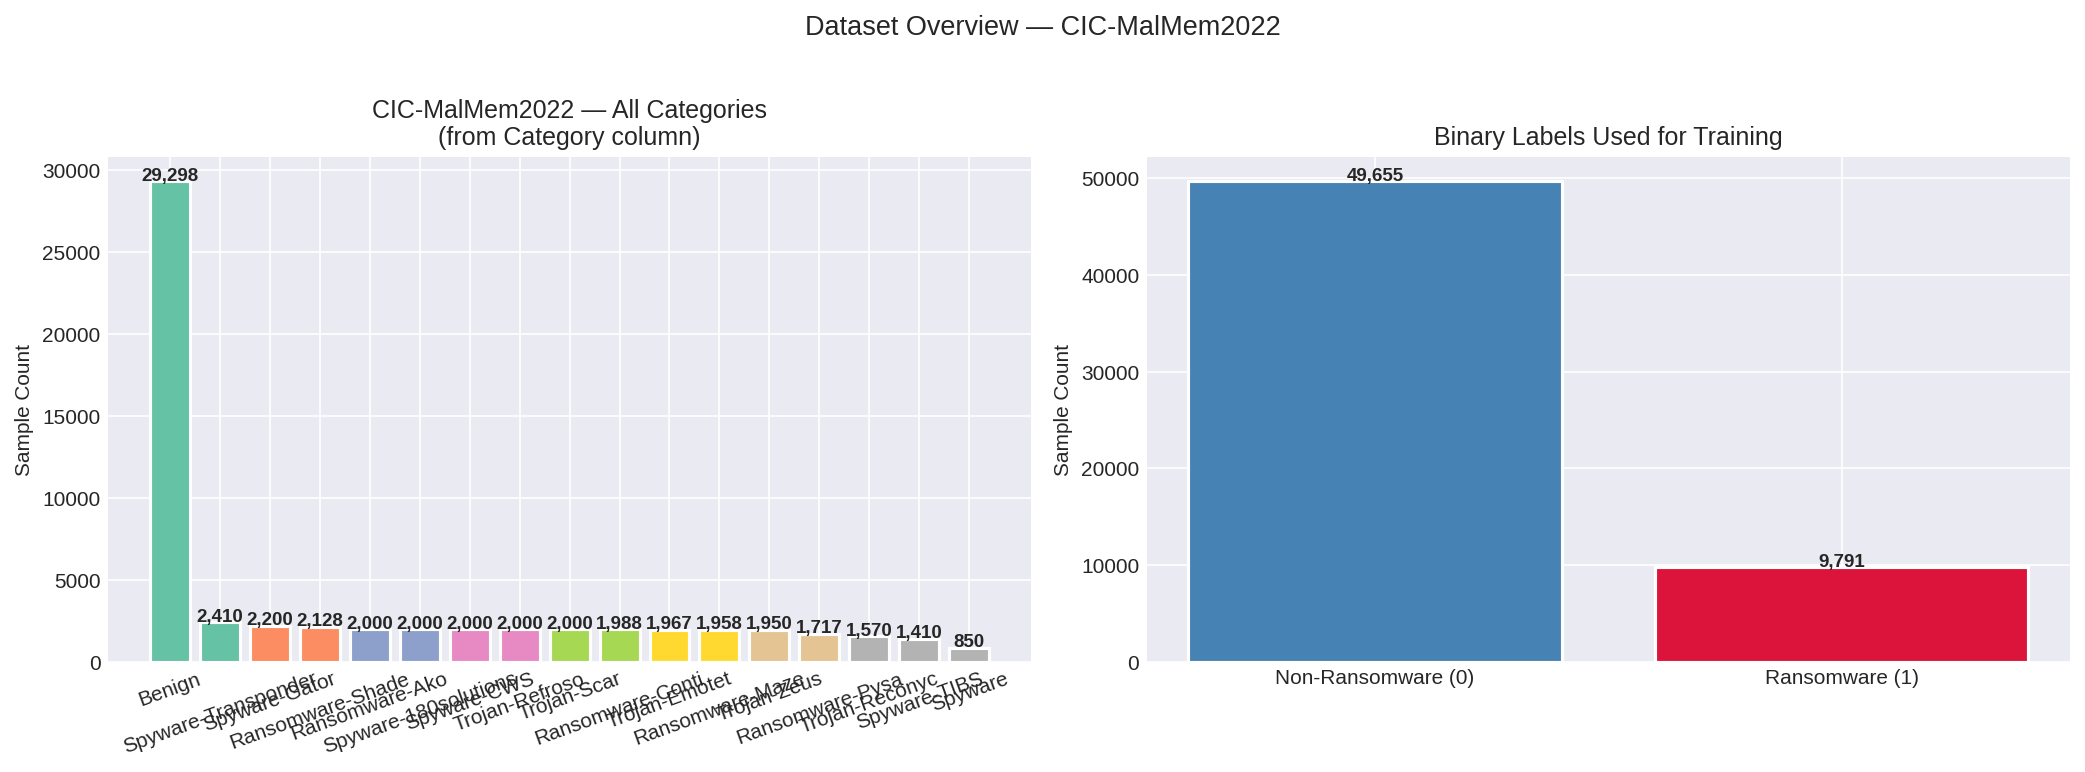

In [57]:
# ── Class distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cc = cat_counts
axes[0].bar(cc.index, cc.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(cc))),
            edgecolor='white', linewidth=1.5)
axes[0].set_title('CIC-MalMem2022 — All Categories\n(from Category column)', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

bc = Counter(y)
axes[1].bar(['Non-Ransomware (0)', 'Ransomware (1)'],
            [bc[0], bc[1]], color=['steelblue','crimson'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Binary Labels Used for Training', fontsize=12)
axes[1].set_ylabel('Sample Count')
for i, v in enumerate([bc[0], bc[1]]):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Dataset Overview — CIC-MalMem2022', fontsize=13, y=1.02)
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'class_distribution.png')
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
show(plot_path)

In [58]:
# ── Feature distributions (top 6 discriminative) ─────────────────────────────
diff = abs(X[y==1].mean() - X[y==0].mean()).sort_values(ascending=False)
top6 = diff.head(6).index.tolist()

print('Top 15 most discriminative features (|mean_ransomware - mean_other|):')
print(diff.head(15).round(4).to_string())

Top 15 most discriminative features (|mean_ransomware - mean_other|):
handles.nhandles                2045.0381
malfind.commitCharge            1221.8717
handles.nevent                   810.7954
dlllist.ndlls                    309.1719
handles.nthread                  242.2726
handles.nsection                 139.4146
handles.nkey                     120.8167
handles.nsemaphore                80.5745
handles.nmutant                   73.0121
handles.nfile                     70.3467
feat_inject_x_hidden              65.8984
feat_handles_per_proc             44.8472
pslist.avg_handlers               44.3298
handles.avg_handles_per_proc      42.4258
malfind.protection                21.9005


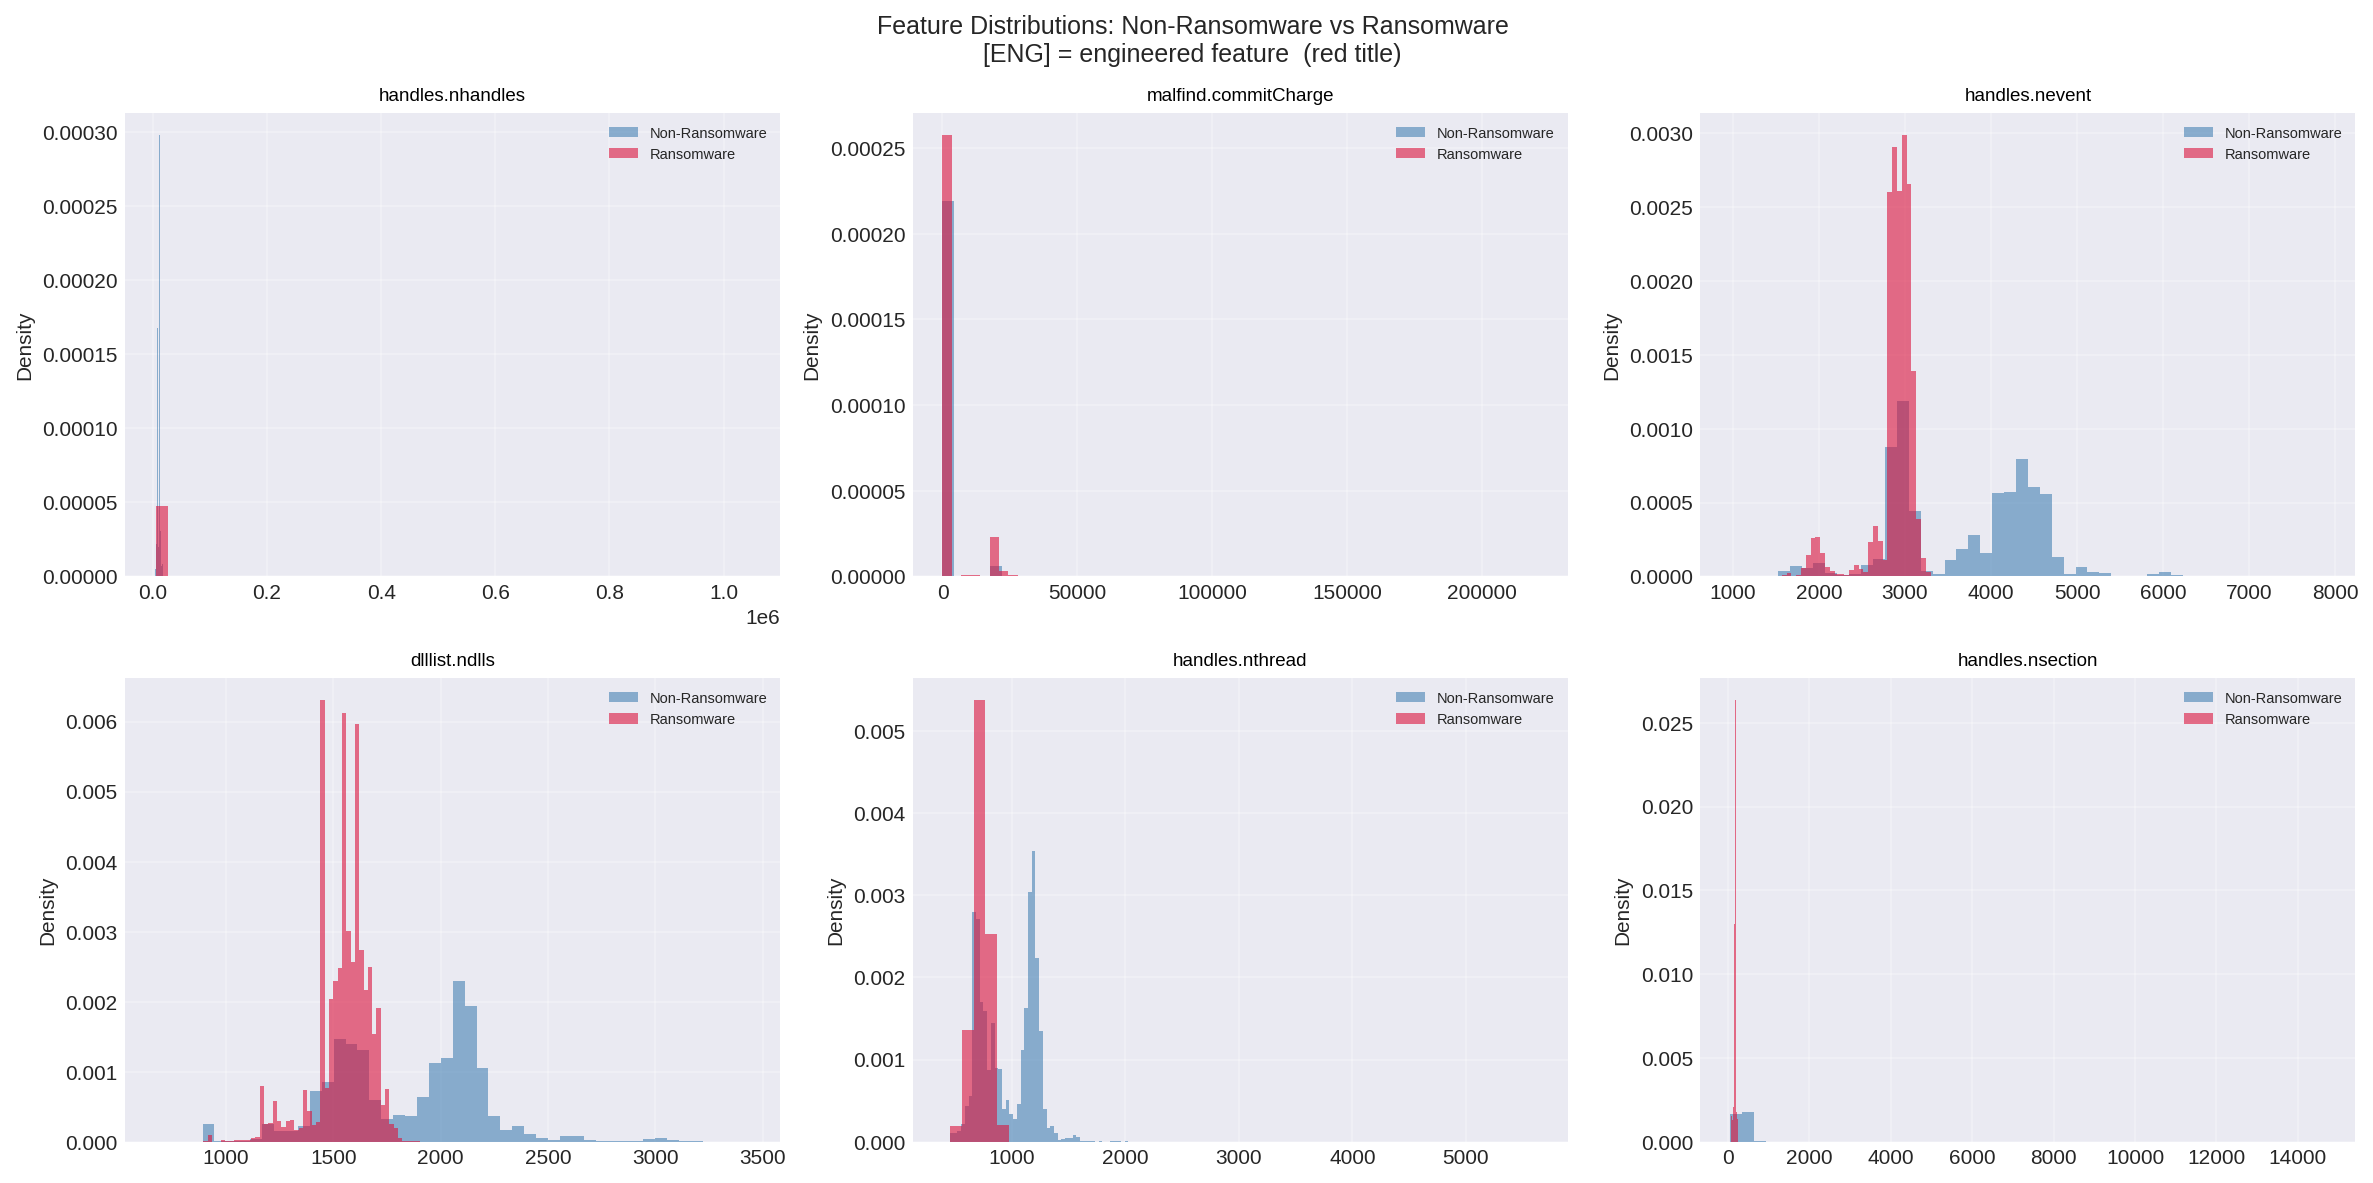

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(top6):
    ax = axes[i]
    color = '#e74c3c' if feat.startswith('feat_') else '#2980b9'
    ax.hist(X.loc[y==0, feat], bins=50, alpha=0.6, color='steelblue',
            label=f'Non-Ransomware', density=True)
    ax.hist(X.loc[y==1, feat], bins=50, alpha=0.6, color='crimson',
            label=f'Ransomware', density=True)
    prefix = '[ENG] ' if feat.startswith('feat_') else ''
    ax.set_title(f'{prefix}{feat}', fontsize=9,
                 color='#c0392b' if feat.startswith('feat_') else 'black')
    ax.legend(fontsize=7); ax.set_ylabel('Density'); ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions: Non-Ransomware vs Ransomware\n'
             '[ENG] = engineered feature  (red title)', fontsize=12)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'feature_distributions.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

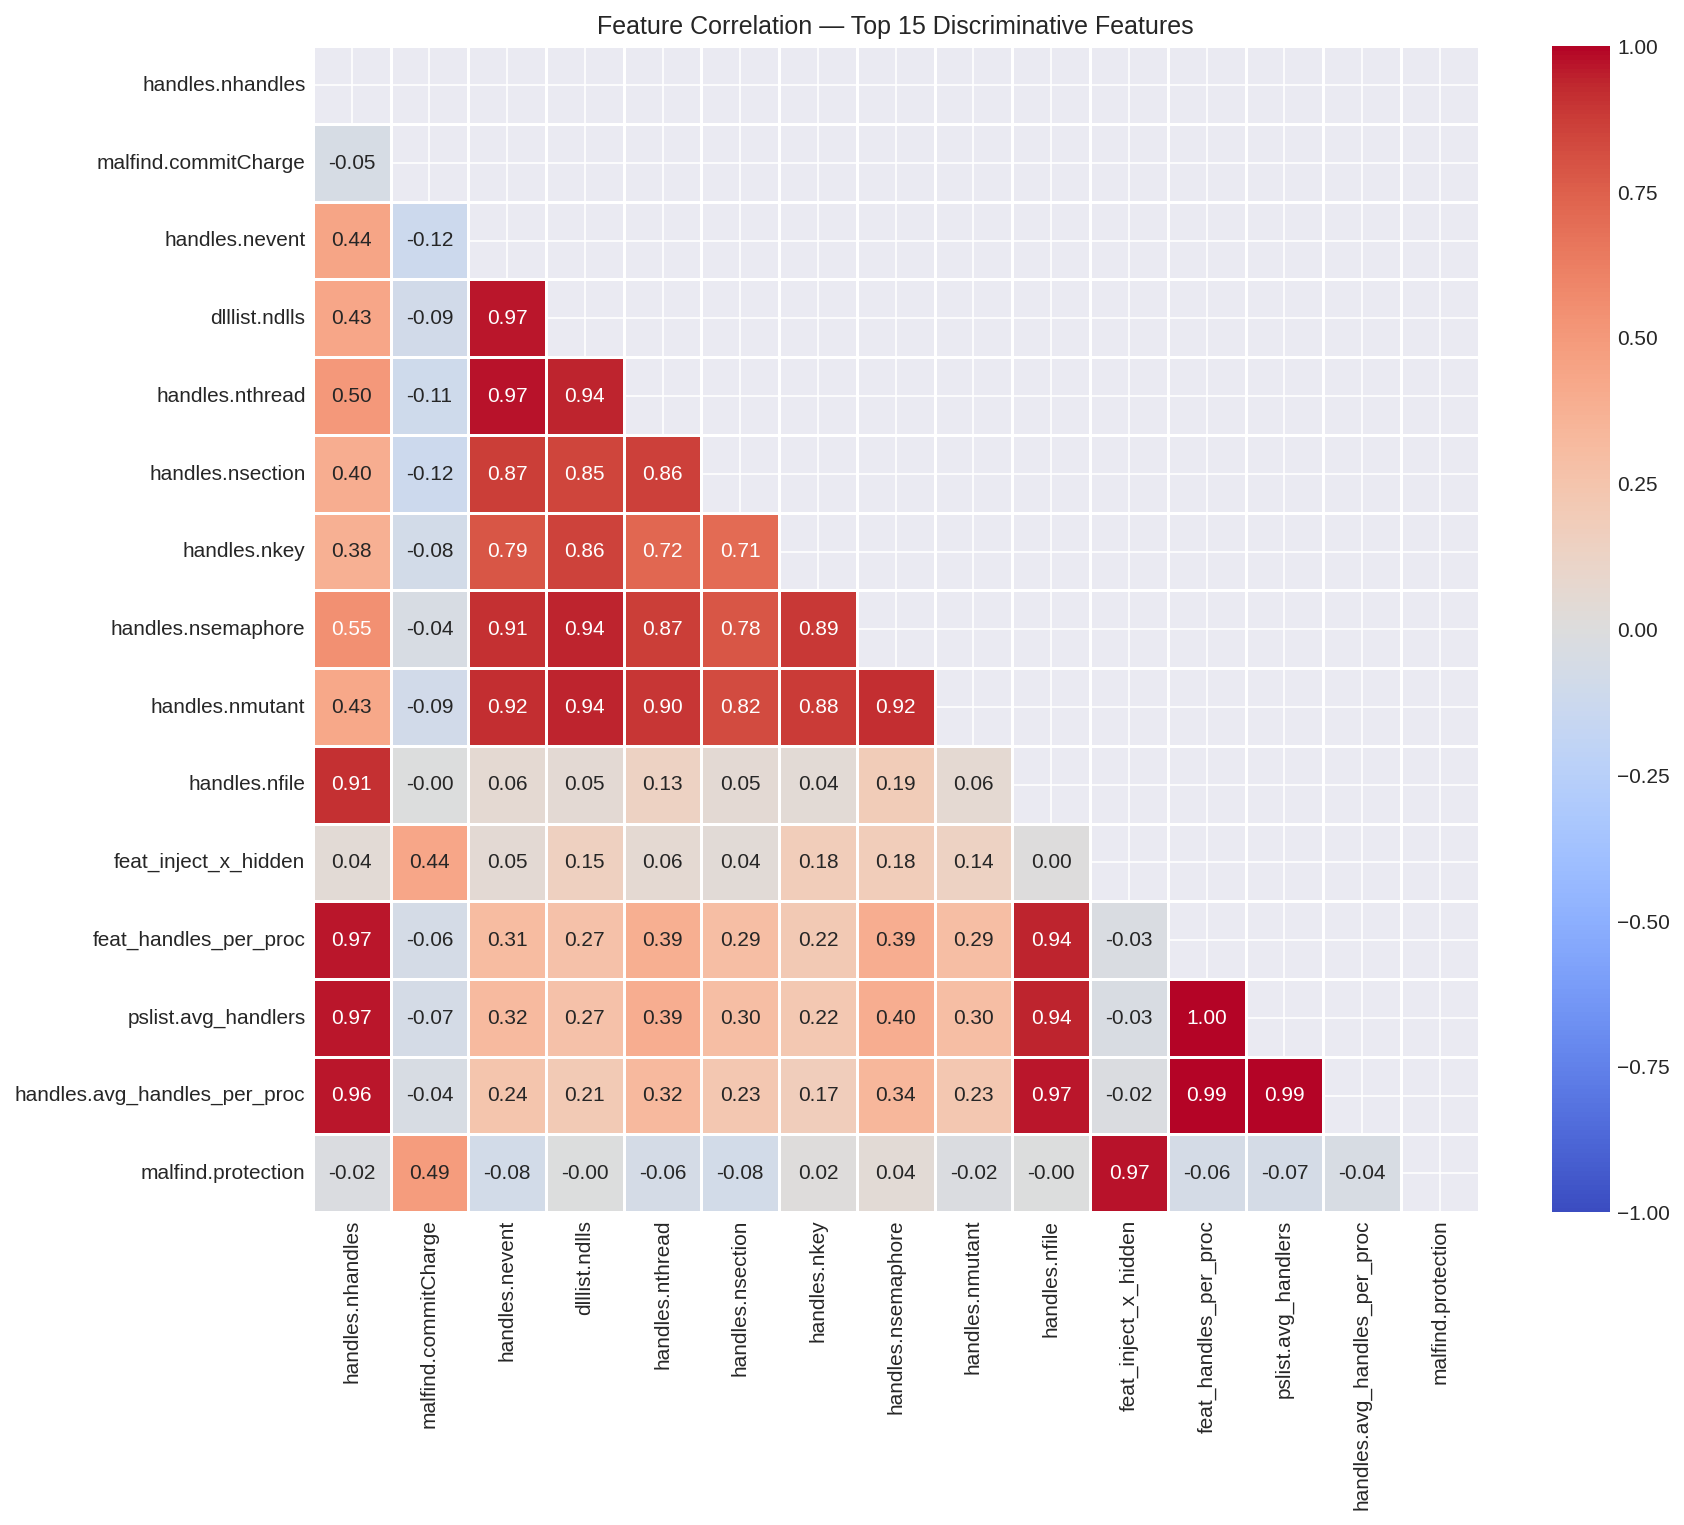

In [60]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
top15 = diff.head(15).index.tolist()
corr  = X[top15].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation — Top 15 Discriminative Features', fontsize=12)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'correlation_heatmap.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

## 2 — Random Forest (Recall-Optimised)

In [61]:
print('='*60)
print('RANDOM FOREST — Supervised | Recall target ≥ 90%')
print('Fix: threshold tuned for recall, NOT F1')
print('Fix: isotonic probability calibration added')
print('='*60)

rf = RansomwareRandomForest(**RF_CONFIG)
rf.feature_names = list(X.columns)

with Timer('RF training'):
    rf_results = rf.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

print(f'\n✓ RF complete')
print(f'  Recall    : {rf_results["recall"]:.4f}  (target ≥ 0.90)')
print(f'  Precision : {rf_results["precision"]:.4f}')
print(f'  F1        : {rf_results["f1"]:.4f}')
print(f'  ROC-AUC   : {rf_results["roc_auc"]:.4f}')
print(f'  Miss Rate : {rf_results["miss_rate"]:.4f}  (fraction of ransomware missed)')
print(f'  Threshold : {rf.threshold:.4f}  (recall-optimised, NOT default 0.5)')

meets = rf_results['recall'] >= 0.90
print(f'\n  {"✓ MEETS" if meets else "✗ BELOW"} recall target')

RANDOM FOREST — Supervised | Recall target ≥ 90%
Fix: threshold tuned for recall, NOT F1
Fix: isotonic probability calibration added

════════════════════════════════════════════════════════════
  RANDOM FOREST — TRAINING PIPELINE
════════════════════════════════════════════════════════════

[RF] Train : 35,667 (5,875 ransomware, 29,792 other)
[RF] Val   : 11,889
[RF] Test  : 11,890
[RF] Before SMOTE: Counter({0: 29792, 1: 5875})
[RF] After  SMOTE: Counter({0: 29792, 1: 29792})

[RF] Training RandomForest (500 trees)...
[RF] OOB Score      : 0.9481
[RF] Calibrating probabilities (isotonic)...

[RF] Threshold sweep (target recall ≥ 90%):
    Thresh    Recall   Precision        F1
      0.05    0.9898      0.3925    0.5621 ← selected
      0.10    0.9632      0.4692    0.6310
      0.15    0.9474      0.4967    0.6517 ← selected
      0.20    0.8820      0.5854    0.7037
      0.35    0.8284      0.6431    0.7241
[RF] Recall target  : 90%
[RF] Optimal thresh : 0.1600

[RF] ── TEST SET ──

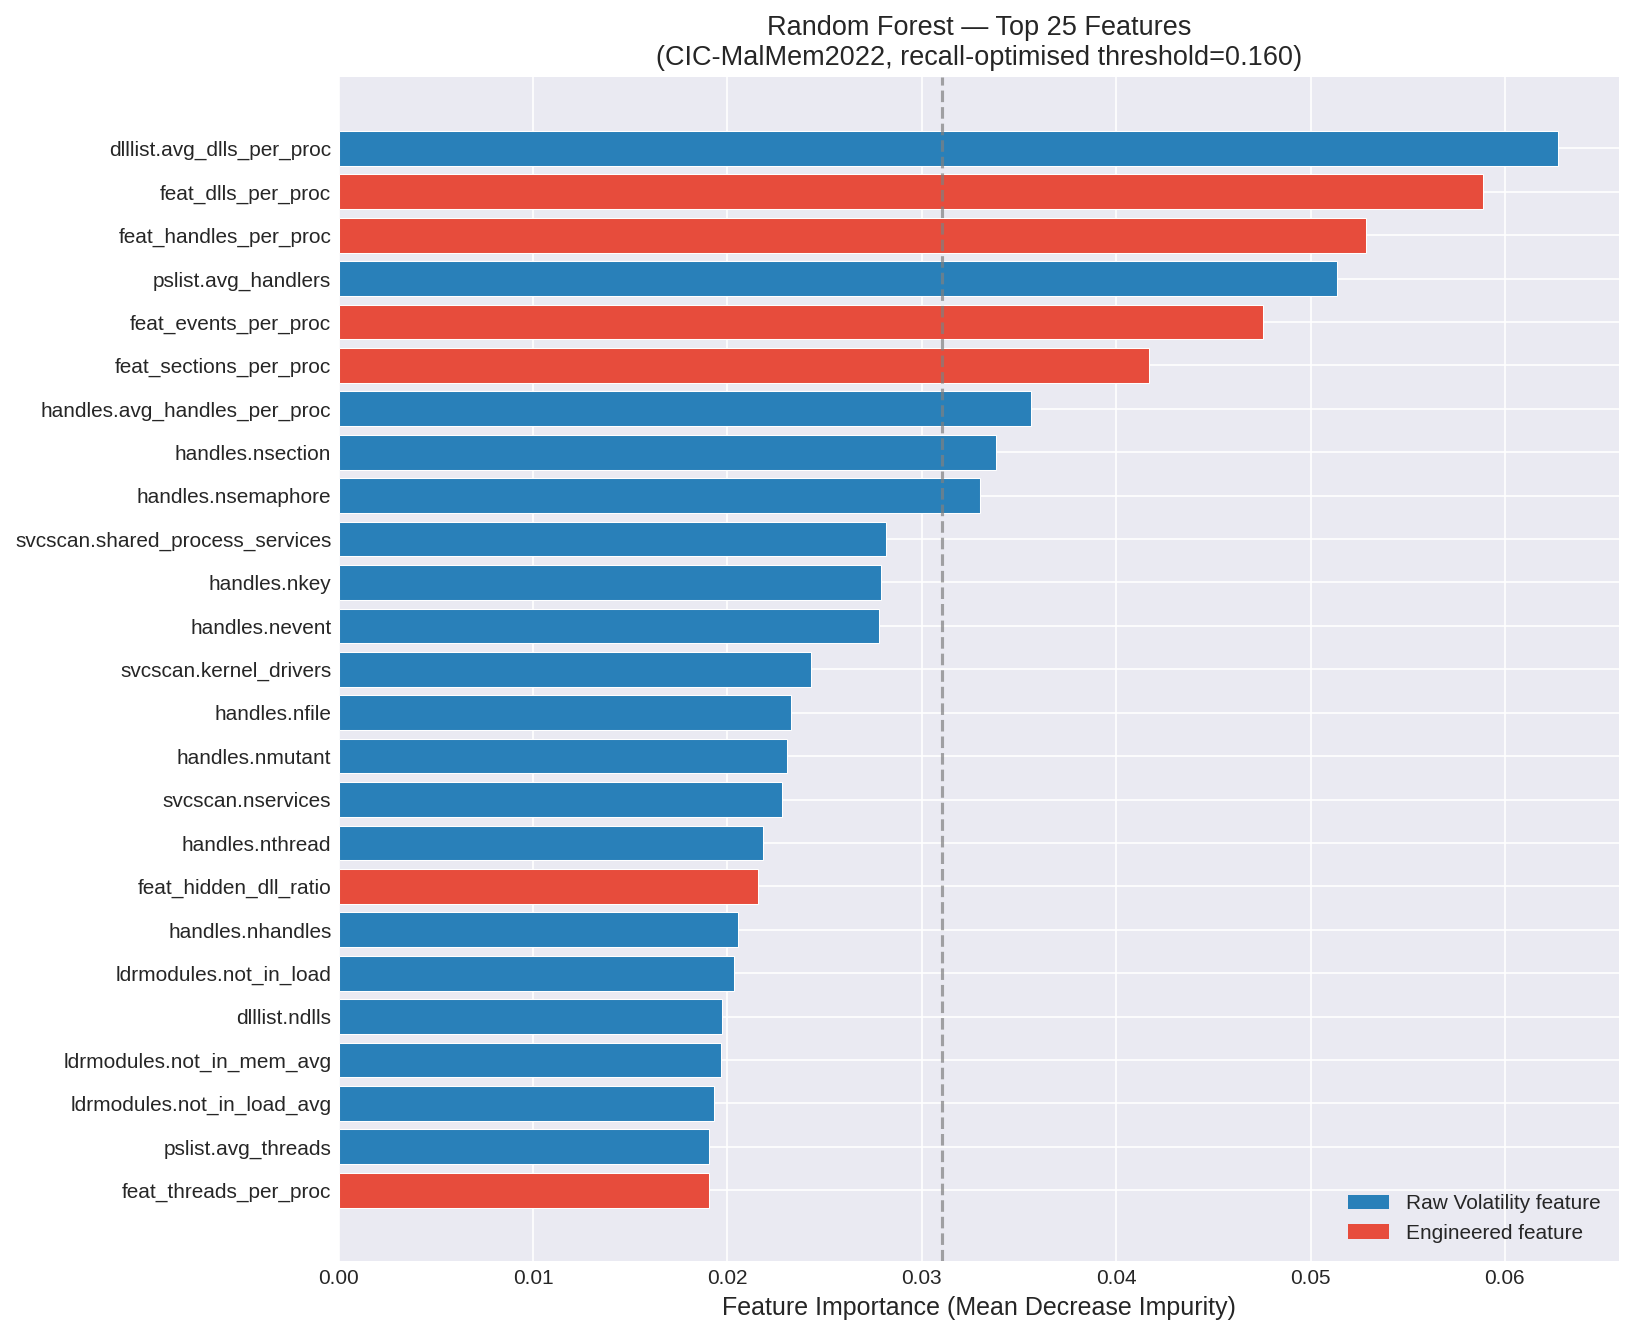


Red bars = engineered features  |  Blue bars = raw Volatility features


In [62]:
rf.plot_feature_importance(top_n=25, save_path=os.path.join(PLOTS_DIR,'rf_feature_importance.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_feature_importance.png'))
print('\nRed bars = engineered features  |  Blue bars = raw Volatility features')

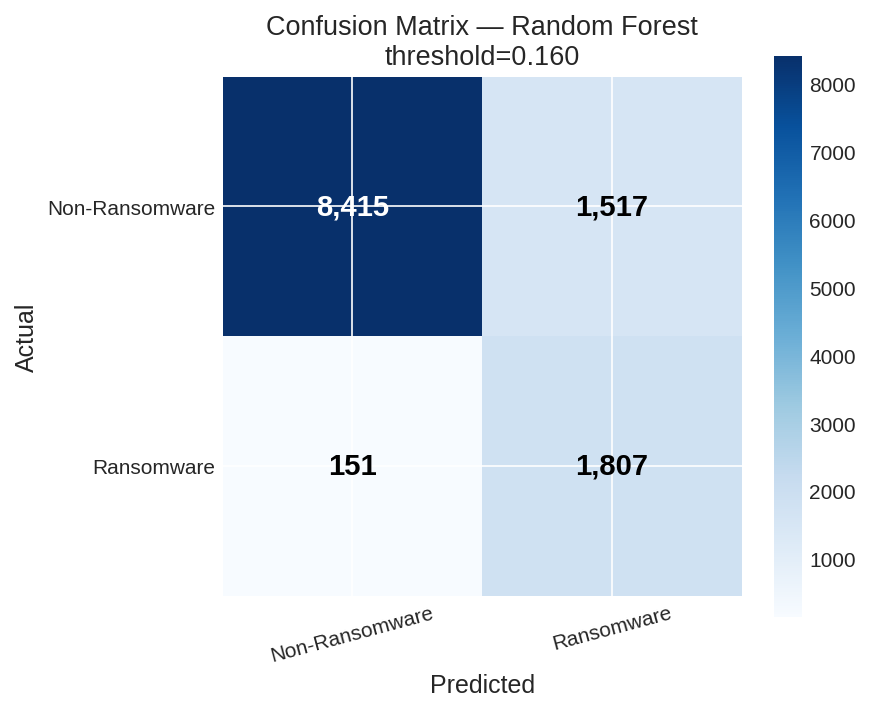


Confusion matrix interpretation:
  True Positives  (ransomware caught)       : 1,807
  False Negatives (ransomware MISSED) ⚠    : 151
  False Positives (false alarms)            : 1,517
  True Negatives  (correct non-ransomware)  : 8,415


In [63]:
rf.plot_confusion_matrix(save_path=os.path.join(PLOTS_DIR,'rf_confusion_matrix.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_confusion_matrix.png'))

cm = rf_results['confusion_matrix']
TN,FP,FN,TP = cm[0][0],cm[0][1],cm[1][0],cm[1][1]
print(f'\nConfusion matrix interpretation:')
print(f'  True Positives  (ransomware caught)       : {TP:,}')
print(f'  False Negatives (ransomware MISSED) ⚠    : {FN:,}')
print(f'  False Positives (false alarms)            : {FP:,}')
print(f'  True Negatives  (correct non-ransomware)  : {TN:,}')

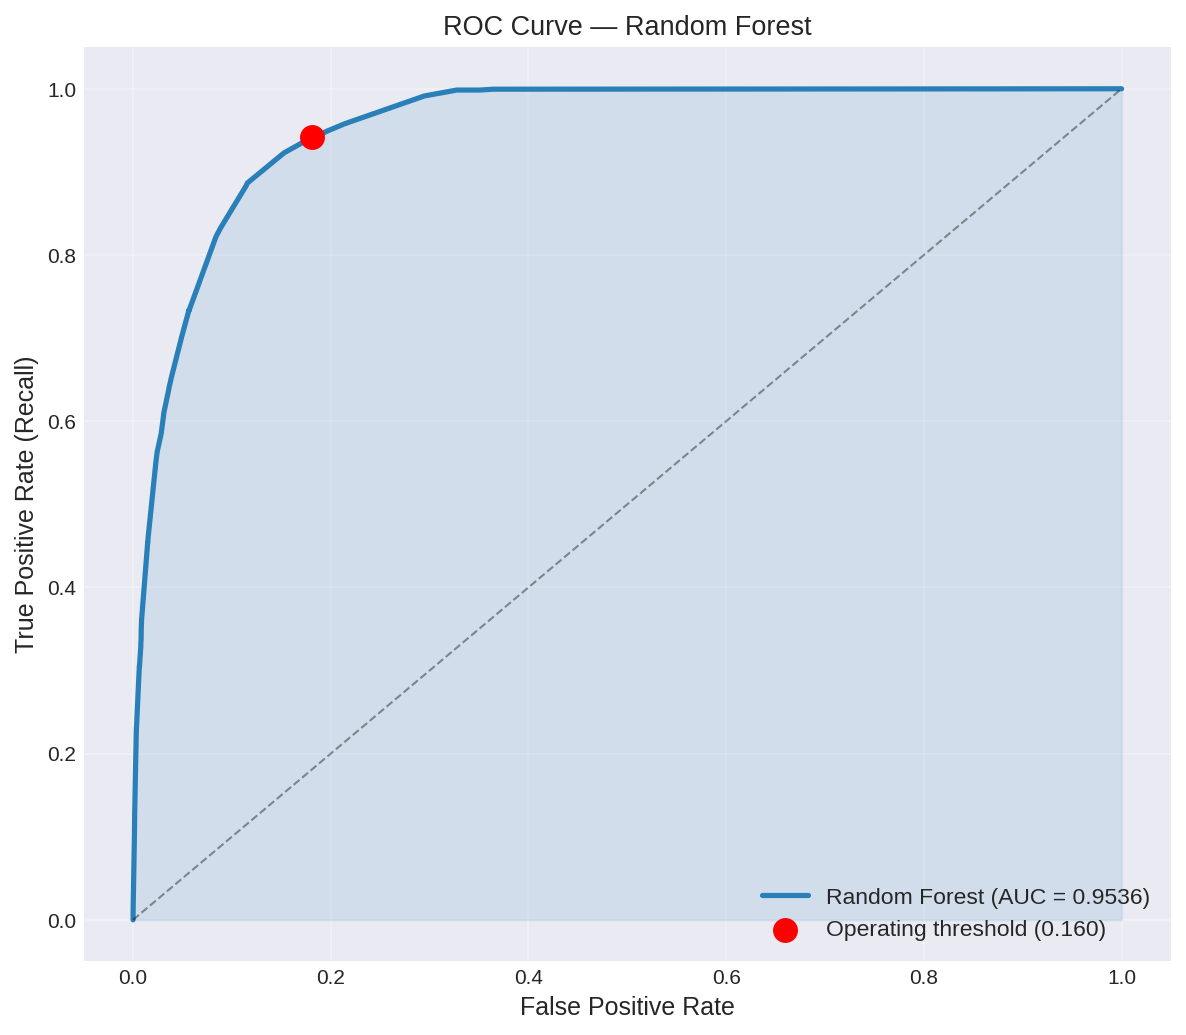

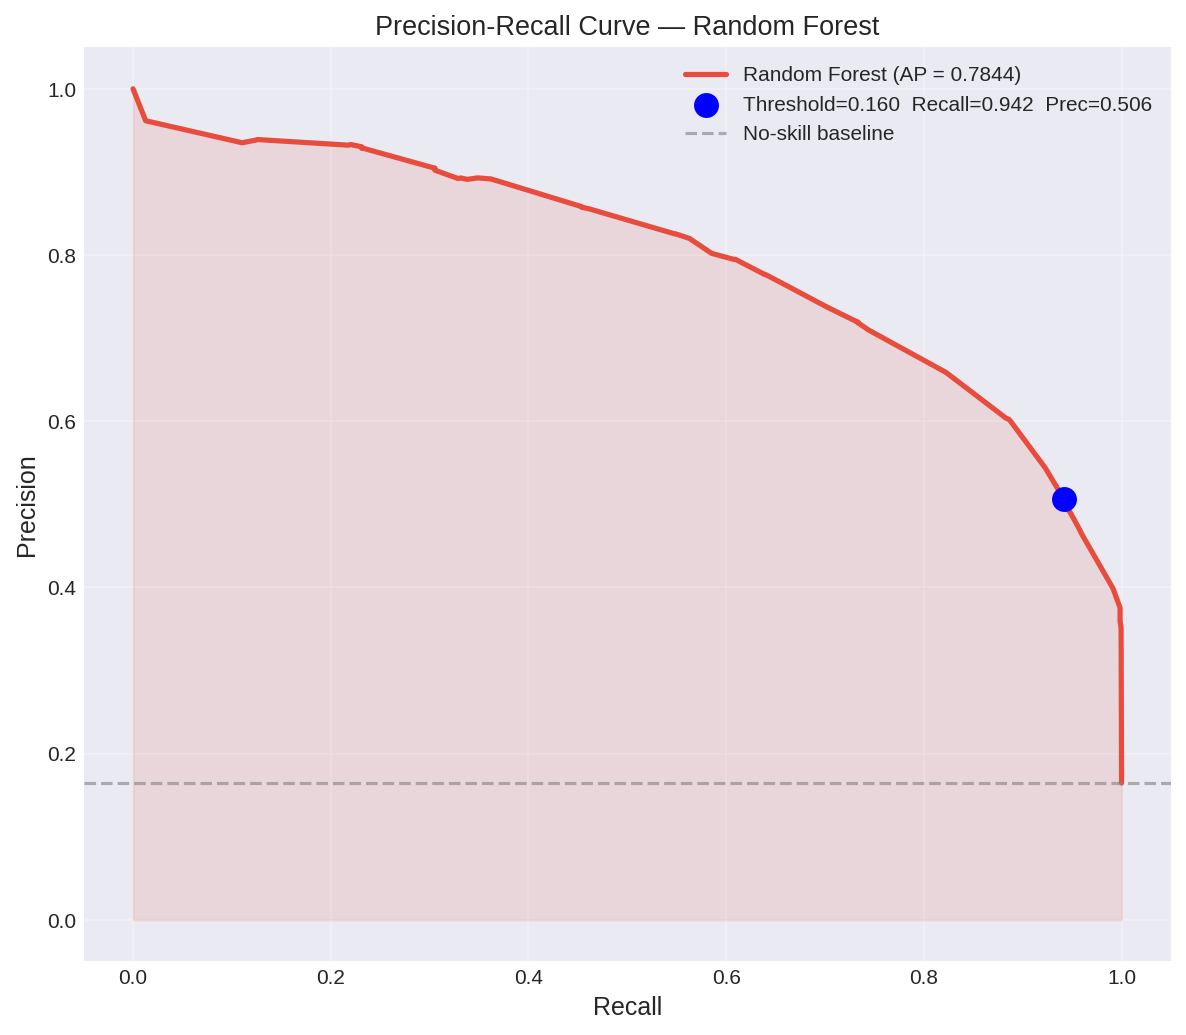

In [64]:
rf.plot_roc_curve(save_path=os.path.join(PLOTS_DIR,'rf_roc_curve.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_roc_curve.png'))

rf.plot_precision_recall_curve(save_path=os.path.join(PLOTS_DIR,'rf_pr_curve.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_pr_curve.png'))

In [65]:
rf.save(
    model_path  = os.path.join(MODELS_DIR, 'random_forest.pkl'),
    scaler_path = os.path.join(MODELS_DIR, 'rf_scaler.pkl'),
)
print('RF saved.')

[RF] Saved model  → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/random_forest.pkl
[RF] Saved scaler → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/rf_scaler.pkl
RF saved.


## 3 — XGBoost

XGBOOST — Supervised | Recall target ≥ 90%
Expected: higher recall than RF on tabular data

════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 35,667 | Val: 11,889 | Test: 11,890
[XGB] Before SMOTE: Counter({0: 29792, 1: 5875})
[XGB] After SMOTE : Counter({0: 29792, 1: 29792})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.1400

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9787    0.8557    0.9131      9932
    Ransomware     0.5530    0.9055    0.6867      1958

      accuracy                         0.8639     11890
     macro avg     0.7659    0.8806    0.7999     11890
  weighted avg     0.9086    0.8639    0.8758     11890

  ROC-AUC: 0.9498 | Avg Precision: 0.7703
[Timer] XGB training: 9.76s

✓ XGB complete
  Recall    : 0.9055
  Precision : 0.5530
  F1

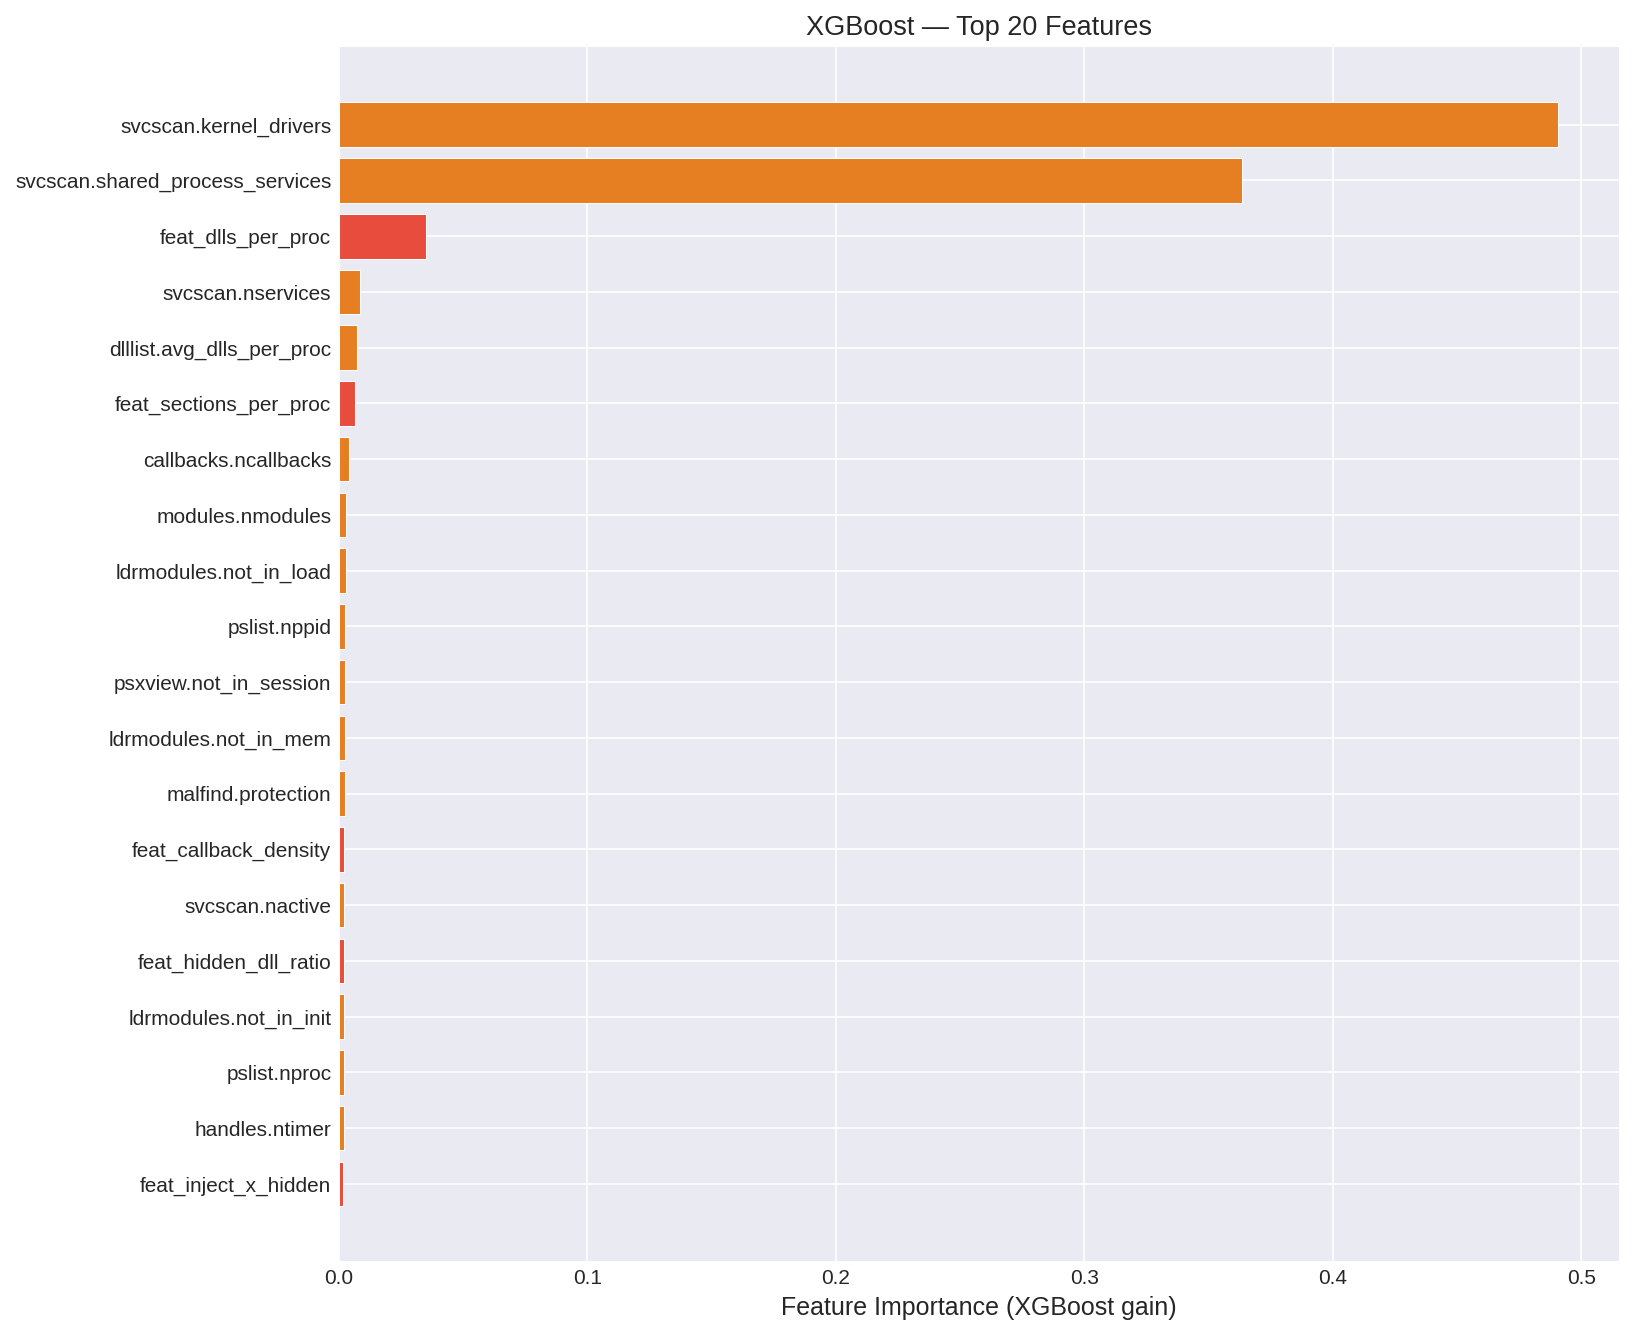

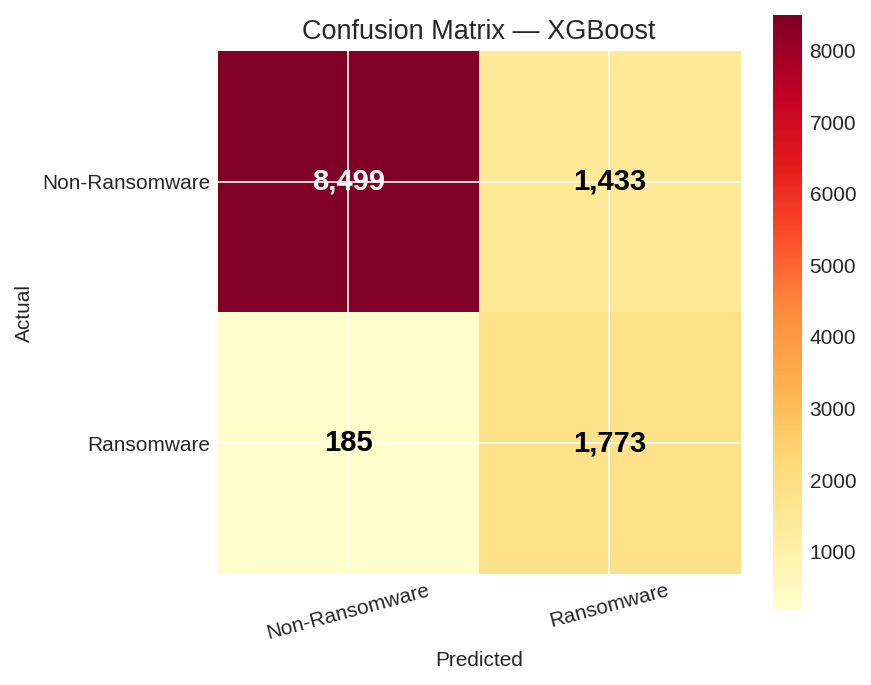

[XGB] Saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/xgboost.pkl


In [66]:
print('='*60)
print('XGBOOST — Supervised | Recall target ≥ 90%')
print('Expected: higher recall than RF on tabular data')
print('='*60)

try:
    xgb_model = RansomwareXGBoost(**XGB_CONFIG)
    xgb_model.feature_names = list(X.columns)

    with Timer('XGB training'):
        xgb_results = xgb_model.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

    print(f'\n✓ XGB complete')
    print(f'  Recall    : {xgb_results["recall"]:.4f}')
    print(f'  Precision : {xgb_results["precision"]:.4f}')
    print(f'  F1        : {xgb_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {xgb_results["roc_auc"]:.4f}')
    print(f'  Threshold : {xgb_model.threshold:.4f}')

    xgb_model.plot_feature_importance(top_n=20,
        save_path=os.path.join(PLOTS_DIR,'xgb_feature_importance.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'xgb_feature_importance.png'))

    xgb_model.plot_confusion_matrix(
        save_path=os.path.join(PLOTS_DIR,'xgb_confusion_matrix.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'xgb_confusion_matrix.png'))

    xgb_model.save(
        path        = os.path.join(MODELS_DIR,'xgboost.pkl'),
        scaler_path = os.path.join(MODELS_DIR,'xgb_scaler.pkl'),
    )
    XGB_OK = True

except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    XGB_OK = False
    xgb_results = {}

## 4 — LightGBM

LIGHTGBM — Supervised | Recall target ≥ 90%
Expected: fastest training, competitive recall

════════════════════════════════════════════════════════════
  LIGHTGBM — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[LGB] Train: 35,667 | Val: 11,889 | Test: 11,890
[LGB] Before SMOTE: Counter({0: 29792, 1: 5875})
[LGB] After SMOTE : Counter({0: 29792, 1: 29792})
[LGB] Training LightGBM...
[LGB] Best iteration: 500
[LGB] Recall-optimised threshold: 0.1500

[LGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9826    0.8496    0.9113      9932
    Ransomware     0.5477    0.9239    0.6877      1958

      accuracy                         0.8618     11890
     macro avg     0.7652    0.8867    0.7995     11890
  weighted avg     0.9110    0.8618    0.8745     11890

  ROC-AUC: 0.9555 | Avg Precision: 0.8008
[Timer] LGB training: 15.58s

✓ LGB complete
  Recall    : 0.9239
  Precision 

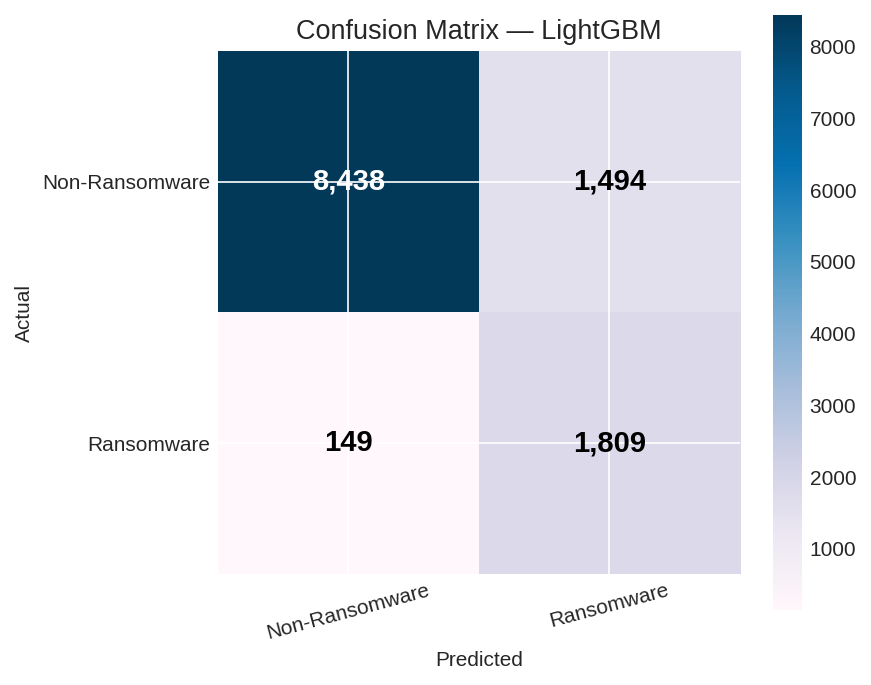

[LGB] Saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/lightgbm.pkl


In [67]:
print('='*60)
print('LIGHTGBM — Supervised | Recall target ≥ 90%')
print('Expected: fastest training, competitive recall')
print('='*60)

try:
    lgb_model = RansomwareLightGBM(**LGB_CONFIG)
    lgb_model.feature_names = list(X.columns)

    with Timer('LGB training'):
        lgb_results = lgb_model.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

    print(f'\n✓ LGB complete')
    print(f'  Recall    : {lgb_results["recall"]:.4f}')
    print(f'  Precision : {lgb_results["precision"]:.4f}')
    print(f'  F1        : {lgb_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {lgb_results["roc_auc"]:.4f}')
    print(f'  Threshold : {lgb_model.threshold:.4f}')

    lgb_model.plot_confusion_matrix(
        save_path=os.path.join(PLOTS_DIR,'lgb_confusion_matrix.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'lgb_confusion_matrix.png'))

    lgb_model.save(
        path        = os.path.join(MODELS_DIR,'lightgbm.pkl'),
        scaler_path = os.path.join(MODELS_DIR,'lgb_scaler.pkl'),
    )
    LGB_OK = True

except ImportError:
    print('LightGBM not installed. Run: pip install lightgbm')
    LGB_OK = False
    lgb_results = {}

## 5 — Isolation Forest (Benign-Only Training — Fixed)

In [68]:
print('='*60)
print('ISOLATION FOREST — Unsupervised Anomaly Detector')
print('FIX v1: trained on Benign-only rows (not mixed non-ransomware)')
print('FIX v2: contamination=0.165 (actual ransomware ratio, was 0.05)')
print('Role: Layer 2 — catches zero-day ransomware not in training labels')
print('='*60)
print(f'\nBenign rows available for training: {int(benign_mask.sum()):,}')
print(f'Total rows                         : {len(y):,}')

iso = RansomwareIsolationForest(**IF_CONFIG)
iso.feature_names = list(X.columns)

with Timer('IF training'):
    if_results = iso.train(X, y, benign_mask=benign_mask, test_size=TEST_SIZE)

print(f'\n✓ IF complete')
print(f'  Recall    : {if_results["recall"]:.4f}')
print(f'  Precision : {if_results["precision"]:.4f}')
print(f'  F1        : {if_results["f1"]:.4f}')
print(f'  ROC-AUC   : {if_results["roc_auc"]:.4f}')
print(f'  Threshold : {iso.threshold:.4f}')
print()
print('Note: IF ROC-AUC of ~0.70–0.80 on static memory data is expected and correct.')
print('IF value is zero-day detection — it was NOT designed to match RF accuracy.')

ISOLATION FOREST — Unsupervised Anomaly Detector
FIX v1: trained on Benign-only rows (not mixed non-ransomware)
FIX v2: contamination=0.165 (actual ransomware ratio, was 0.05)
Role: Layer 2 — catches zero-day ransomware not in training labels

Benign rows available for training: 29,298
Total rows                         : 59,446

════════════════════════════════════════════════════════════
  ISOLATION FOREST — TRAINING PIPELINE
════════════════════════════════════════════════════════════

[IF] Training mode: BENIGN-ONLY (Category == 'Benign')
[IF] Benign training samples : 23,341
[IF] Test set (both classes)  : 11,890
[IF]   Ransomware    : 1,958
[IF]   Non-ransomware: 9,932
[IF] Contamination param       : 0.165

[IF] Training IsolationForest (300 trees)...
[IF] Training complete.
[IF] Optimal threshold: -0.6100

[IF] ── TEST SET ──────────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9835    0.6312    0.7689      9932
    R

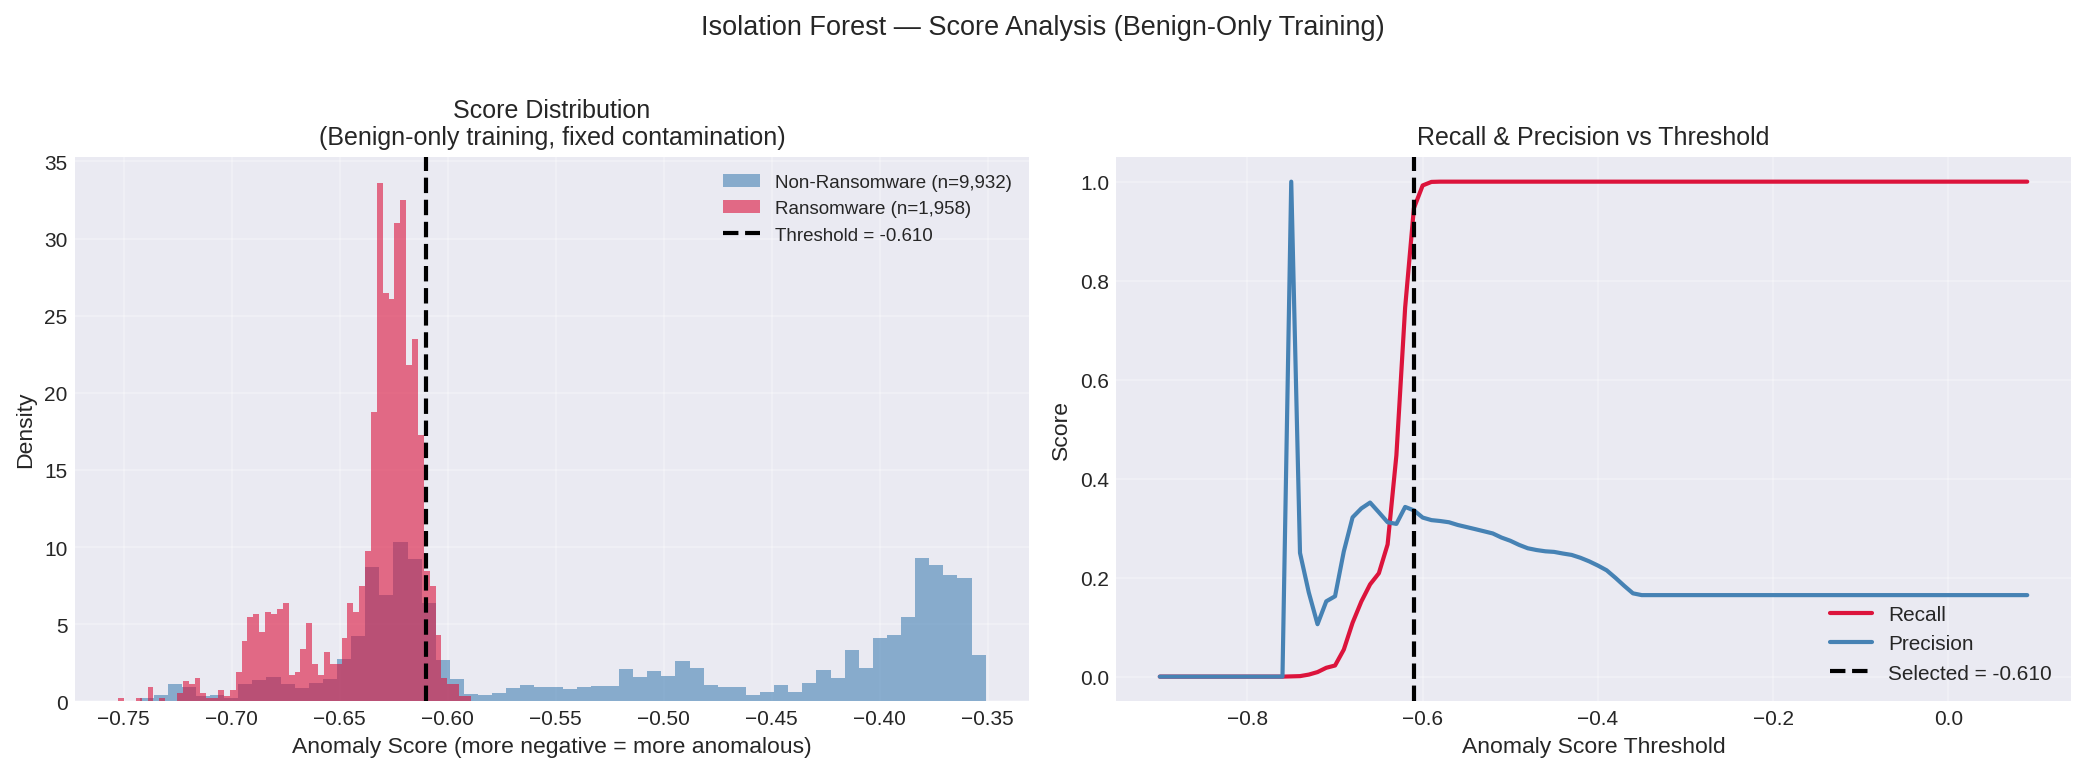

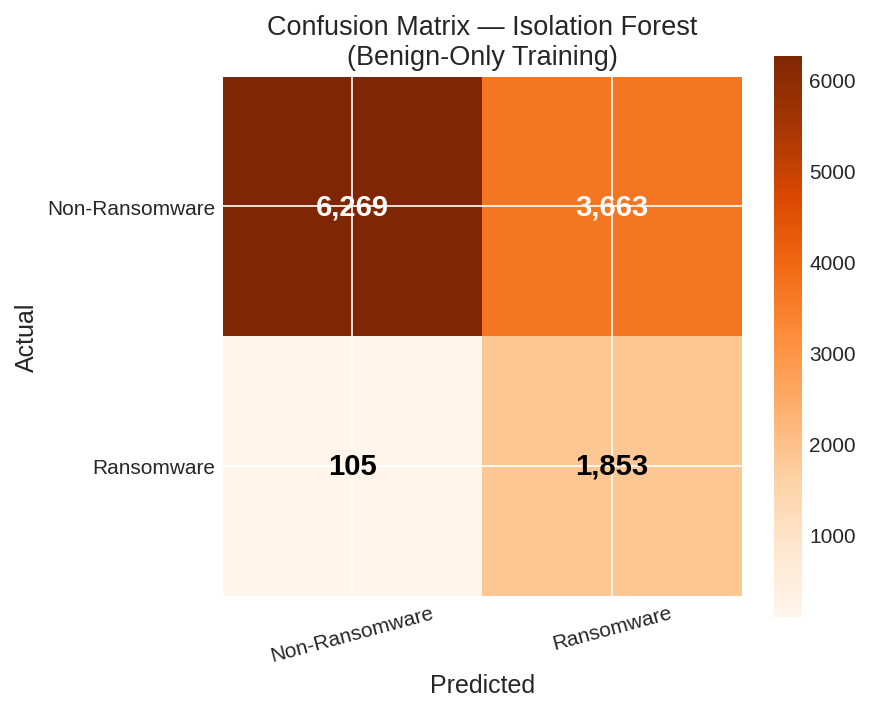

[IF] Saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/isolation_forest.pkl
IF saved.


In [69]:
iso.plot_score_distribution(
    save_path=os.path.join(PLOTS_DIR,'if_score_distribution.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'if_score_distribution.png'))

iso.plot_confusion_matrix(
    save_path=os.path.join(PLOTS_DIR,'if_confusion_matrix.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'if_confusion_matrix.png'))

iso.save(
    model_path  = os.path.join(MODELS_DIR,'isolation_forest.pkl'),
    scaler_path = os.path.join(MODELS_DIR,'if_scaler.pkl'),
)
print('IF saved.')

## 6 — Deep Autoencoder (Replaces LSTM)

DEEP AUTOENCODER — Unsupervised Anomaly Detector
Replaces the LSTM which was wrong for static tabular data.
Architecture: 70 → 128 → 64 → 32 → 16 → 32 → 64 → 128 → 70
Trained on Benign-only rows.
Detects ransomware via high reconstruction error.
TensorFlow 2.21.0 found.

════════════════════════════════════════════════════════════
  DEEP AUTOENCODER — TRAINING PIPELINE
════════════════════════════════════════════════════════════

[AE] Training mode   : BENIGN-ONLY (Category == 'Benign')
[AE] Training samples: 23,341
[AE] Test set        : 11,890 (1,958 ransomware, 9,932 non-ransomware)
[AE] Architecture    : 69 → 128 → 64 → 32 → 16 → 32 → 64 → 128 → 69

[AE] Building model...


Model: "Deep_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_0 (Dense)                   │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_0 (Activation)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_0 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_1 (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_2 (Activation)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_2 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_0 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_0 (Activation)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_0 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_1 (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_2 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_2 (Activation)          │ (None, 128)            │             

 Total params: 41,493 (162.08 KB)

 Trainable params: 40,597 (158.58 KB)

 Non-trainable params: 896 (3.50 KB)


[AE] Training (up to 100 epochs, patience=15)...
Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.2977 - mae: 0.7512 - val_loss: 0.7711 - val_mae: 0.5445 - learning_rate: 5.0000e-04
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8167 - mae: 0.5741 - val_loss: 0.5618 - val_mae: 0.4265 - learning_rate: 5.0000e-04
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6376 - mae: 0.5060 - val_loss: 0.4571 - val_mae: 0.3748 - learning_rate: 5.0000e-04
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5561 - mae: 0.4706 - val_loss: 0.4262 - val_mae: 0.3571 - learning_rate: 5.0000e-04
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4996 - mae: 0.4433 - val_loss: 0.3774 - val_mae: 0.3320 - learning_rate: 5.0000e-04
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4521 - mae: 0.4212 - val_loss: 0.3192 - val_mae: 0.3146 - learning_rate: 5.0000e-04
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4103 - mae: 0.4026

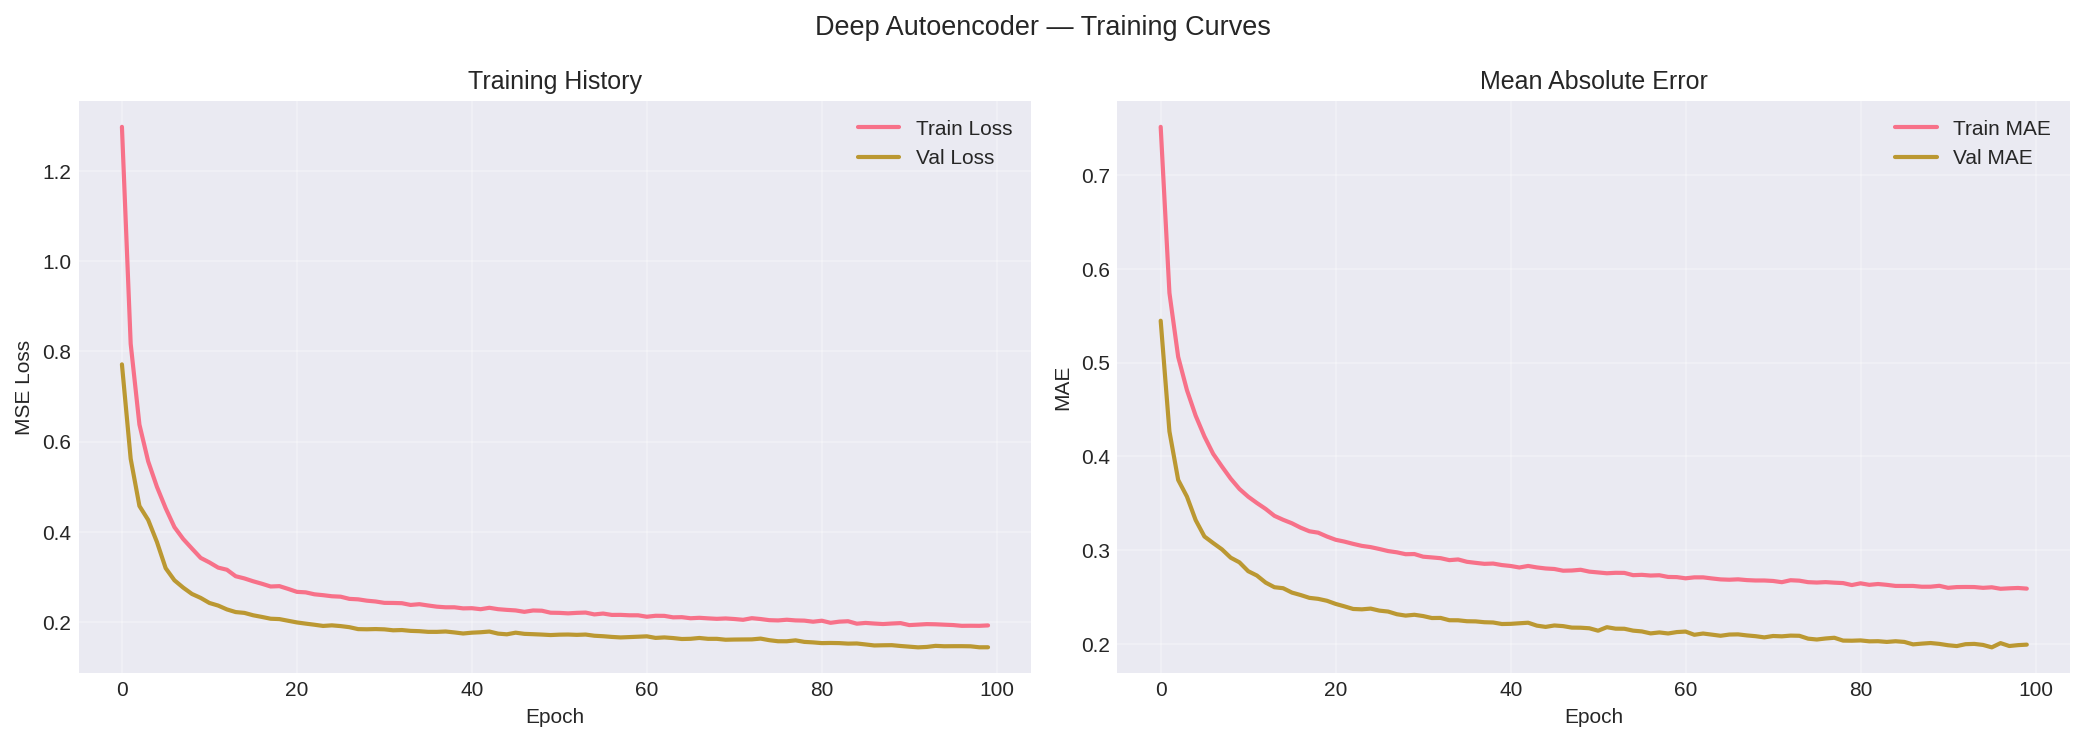

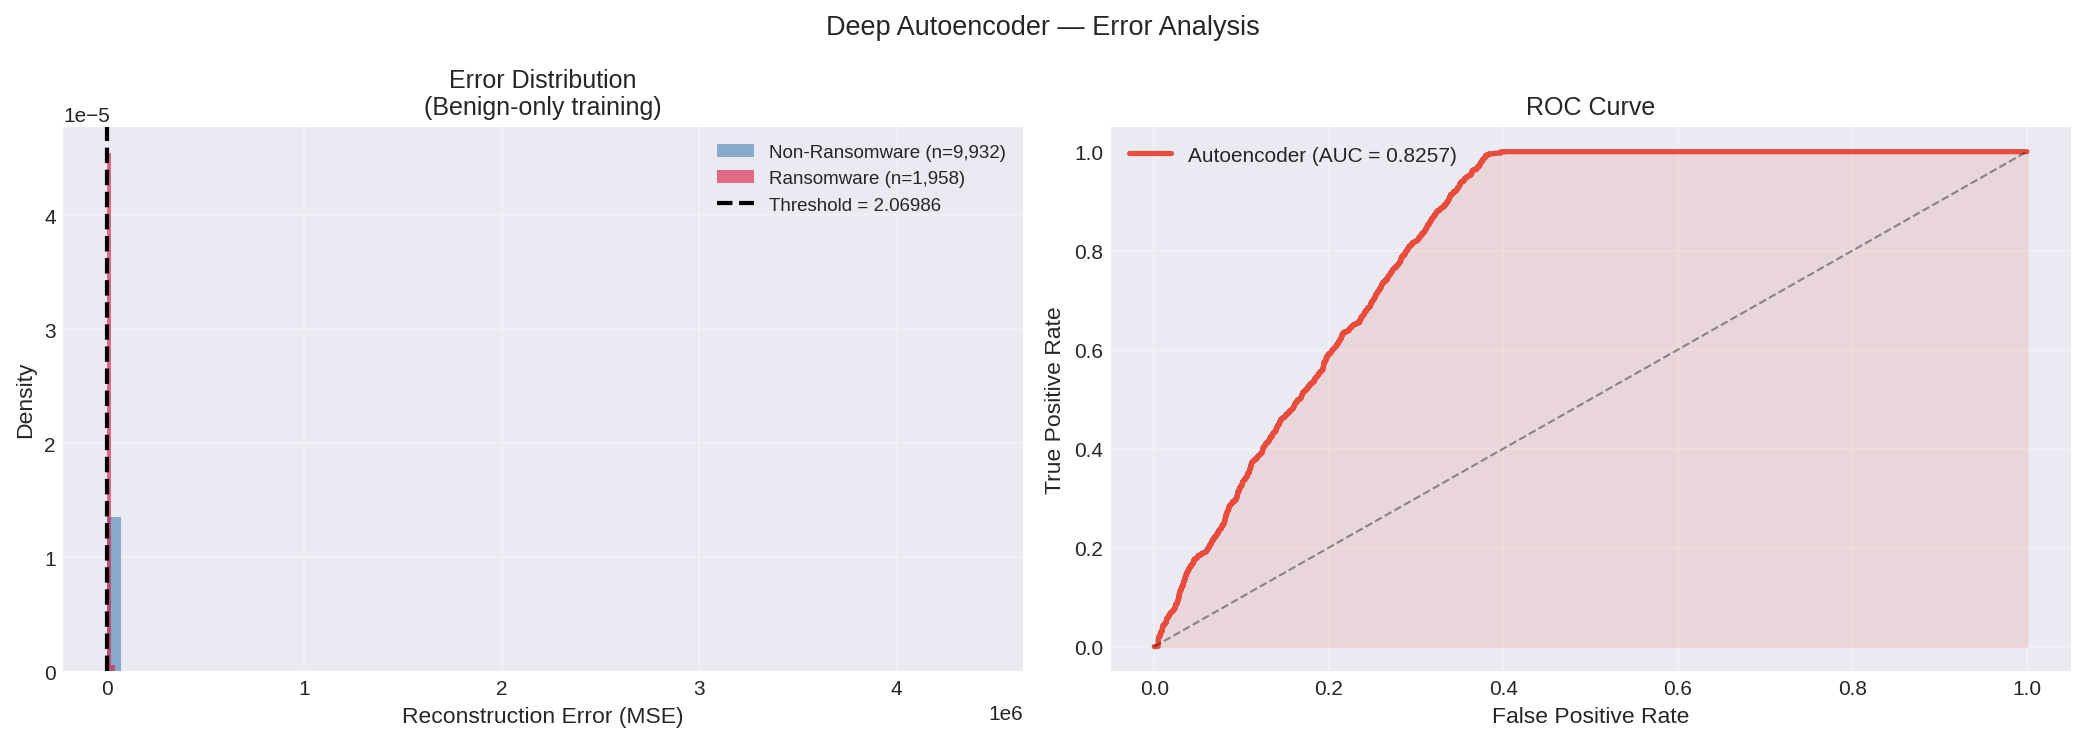

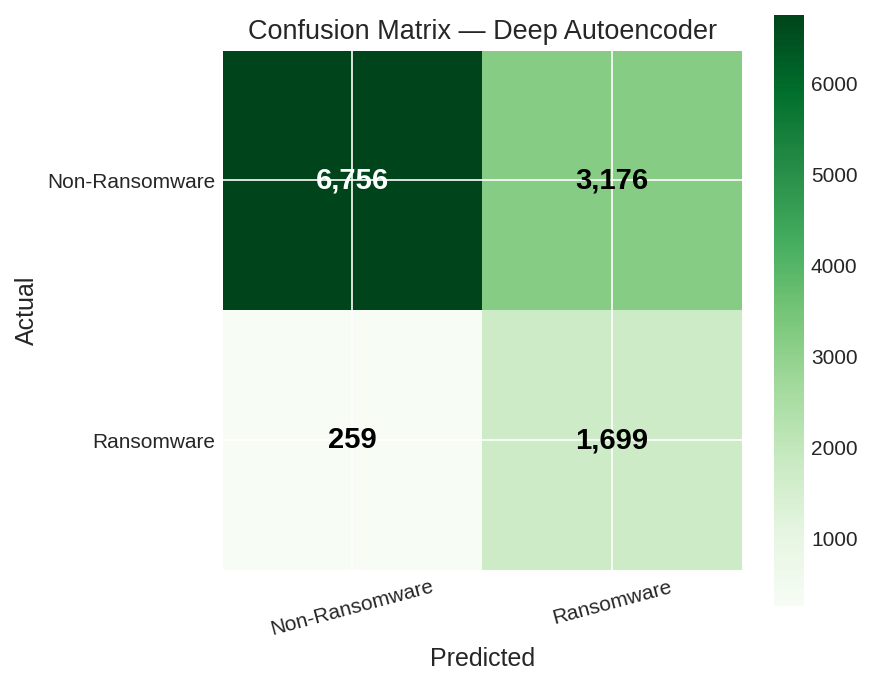

[AE] Saved model → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/autoencoder/model.keras
[AE] Saved meta  → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/autoencoder/meta.json


In [70]:
print('='*60)
print('DEEP AUTOENCODER — Unsupervised Anomaly Detector')
print('Replaces the LSTM which was wrong for static tabular data.')
print('Architecture: 70 → 128 → 64 → 32 → 16 → 32 → 64 → 128 → 70')
print('Trained on Benign-only rows.')
print('Detects ransomware via high reconstruction error.')
print('='*60)

AE_OK = False
ae_results = {}

try:
    import tensorflow as tf
    print(f'TensorFlow {tf.__version__} found.')

    ae = RansomwareAutoencoder(**AE_CONFIG)
    ae.feature_names = list(X.columns)
    ae.n_features    = len(X.columns)

    with Timer('AE training'):
        ae_results = ae.train(X, y, benign_mask=benign_mask, test_size=TEST_SIZE)

    print(f'\n✓ AE complete')
    print(f'  Recall    : {ae_results["recall"]:.4f}')
    print(f'  Precision : {ae_results["precision"]:.4f}')
    print(f'  F1        : {ae_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {ae_results["roc_auc"]:.4f}')
    print(f'  Threshold : {ae.threshold:.6f}')

    ae.plot_training_history(
        save_path=os.path.join(PLOTS_DIR,'ae_training_history.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'ae_training_history.png'))

    ae.plot_error_distribution(
        save_path=os.path.join(PLOTS_DIR,'ae_error_distribution.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'ae_error_distribution.png'))

    ae.plot_confusion_matrix(
        save_path=os.path.join(PLOTS_DIR,'ae_confusion_matrix.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'ae_confusion_matrix.png'))

    ae.save(
        model_dir   = os.path.join(MODELS_DIR,'autoencoder'),
        scaler_path = os.path.join(MODELS_DIR,'ae_scaler.pkl'),
    )
    AE_OK = True

except ImportError:
    print('TensorFlow not installed. pip install tensorflow')

## 7 — Weighted Ensemble

In [71]:
print('='*60)
print('WEIGHTED ENSEMBLE — Soft-voting of all trained models')
print('Weights: RF=0.35, XGB=0.35, LGB=0.20, AE=0.10')
print('='*60)

ens = RansomwareEnsemble(recall_target=0.90)
ens.add_model('random_forest', rf)
if XGB_OK: ens.add_model('xgboost',   xgb_model)
if LGB_OK: ens.add_model('lightgbm',  lgb_model)
if AE_OK:  ens.add_model('autoencoder', ae)

if len(ens.models) >= 2:
    with Timer('Ensemble evaluation'):
        ens_results = ens.evaluate(X, y, test_size=TEST_SIZE)

    print(f'\n✓ Ensemble complete')
    print(f'  Recall    : {ens_results["recall"]:.4f}')
    print(f'  Precision : {ens_results["precision"]:.4f}')
    print(f'  F1        : {ens_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {ens_results["roc_auc"]:.4f}')
    print(f'  Threshold : {ens.threshold:.4f}')
    ENS_OK = True
else:
    print('Need ≥2 trained models for ensemble.')
    ens_results = {}; ENS_OK = False

WEIGHTED ENSEMBLE — Soft-voting of all trained models
Weights: RF=0.35, XGB=0.35, LGB=0.20, AE=0.10
[ENS] Recall-optimised threshold: 0.1800

[ENS] ── ENSEMBLE TEST SET ──────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9790    0.8654    0.9187      9932
    Ransomware     0.5702    0.9060    0.6999      1958

      accuracy                         0.8721     11890
     macro avg     0.7746    0.8857    0.8093     11890
  weighted avg     0.9117    0.8721    0.8827     11890

  ROC-AUC: 0.9560 | Avg Precision: 0.8083
[Timer] Ensemble evaluation: 3.77s

✓ Ensemble complete
  Recall    : 0.9060
  Precision : 0.5702
  F1        : 0.6999
  ROC-AUC   : 0.9560
  Threshold : 0.1800


In [72]:
# Build comparison table manually without using all_metrics loop
from sklearn.metrics import roc_curve
import numpy as np

all_metrics = []
models_probas = {}
operating_pts = {}

def register(name, res, model_obj):
    if not res: return
    y_t = np.array(res.get('y_test', []))
    p   = np.array(res.get('test_proba', res.get('test_errors', [])))
    if len(y_t) == 0 or len(p) == 0: return
    t    = getattr(model_obj, 'threshold', 0.5)
    pred = (p >= t).astype(int)
    m    = security_metrics(y_t, pred, p, name)
    all_metrics.append(m)
    models_probas[name] = (y_t, p)
    operating_pts[name] = t

register('Random Forest',    rf_results,  rf)
register('XGBoost',          xgb_results, xgb_model)
register('LightGBM',         lgb_results, lgb_model)
register('Isolation Forest', if_results,  iso)
if AE_OK: register('Autoencoder', ae_results, ae)
register('Ensemble',         ens_results, ens)

comp_df = build_comparison_table(all_metrics)


════════════════════════════════════════════════════════════════════════════════════════════════════
  MODEL COMPARISON TABLE  (sorted by Recall — most important metric in security)
════════════════════════════════════════════════════════════════════════════════════════════════════
        model recall precision     f1 roc_auc avg_precision miss_rate  meets_target
     LightGBM 0.9239    0.5477 0.6877  0.9555        0.8008    0.0761          True
Random Forest 0.9229    0.5436 0.6842  0.9536        0.7844    0.0771          True
     Ensemble 0.9060    0.5702 0.6999  0.9560        0.8083    0.0940          True
      XGBoost 0.9055    0.5530 0.6867  0.9498        0.7703    0.0945          True
  Autoencoder 0.8677    0.3485 0.4973  0.0000        0.0000    0.1323         False
════════════════════════════════════════════════════════════════════════════════════════════════════
  LightGBM              : Recall=0.9239 ✓ MEETS TARGET
  Random Forest         : Recall=0.9229 ✓ MEETS TARGET
 

## 8 — Model Comparison

In [73]:
from sklearn.metrics import roc_auc_score
import numpy as np

# ── Build metrics list for all trained models ─────────────────────────────────
all_metrics   = []
models_probas = {}   # for combined ROC + PR plot
operating_pts = {}   # threshold per model

def register(name, res, model_obj):
    if not res:
        return
    y_t = np.array(res.get('y_test', []))
    p   = np.array(res.get('test_proba', res.get('test_errors', [])))
    if len(y_t) == 0 or len(p) == 0:
        return
    t   = getattr(model_obj, 'threshold', 0.5)
    pred= (p >= t).astype(int)
    m   = security_metrics(y_t, pred, p, name)
    all_metrics.append(m)
    models_probas[name] = (y_t, p)
    operating_pts[name] = t

register('Random Forest',    rf_results,  rf)
if XGB_OK: register('XGBoost',       xgb_results, xgb_model)
if LGB_OK: register('LightGBM',      lgb_results, lgb_model)
register('Isolation Forest', if_results,  iso)
if AE_OK:  register('Autoencoder',   ae_results,  ae)
if ENS_OK: register('Ensemble',      ens_results, ens)

comp_df = build_comparison_table(all_metrics)


════════════════════════════════════════════════════════════════════════════════════════════════════
  MODEL COMPARISON TABLE  (sorted by Recall — most important metric in security)
════════════════════════════════════════════════════════════════════════════════════════════════════
        model recall precision     f1 roc_auc avg_precision miss_rate  meets_target
     LightGBM 0.9239    0.5477 0.6877  0.9555        0.8008    0.0761          True
Random Forest 0.9229    0.5436 0.6842  0.9536        0.7844    0.0771          True
     Ensemble 0.9060    0.5702 0.6999  0.9560        0.8083    0.0940          True
      XGBoost 0.9055    0.5530 0.6867  0.9498        0.7703    0.0945          True
  Autoencoder 0.8677    0.3485 0.4973  0.0000        0.0000    0.1323         False
════════════════════════════════════════════════════════════════════════════════════════════════════
  LightGBM              : Recall=0.9239 ✓ MEETS TARGET
  Random Forest         : Recall=0.9229 ✓ MEETS TARGET
 

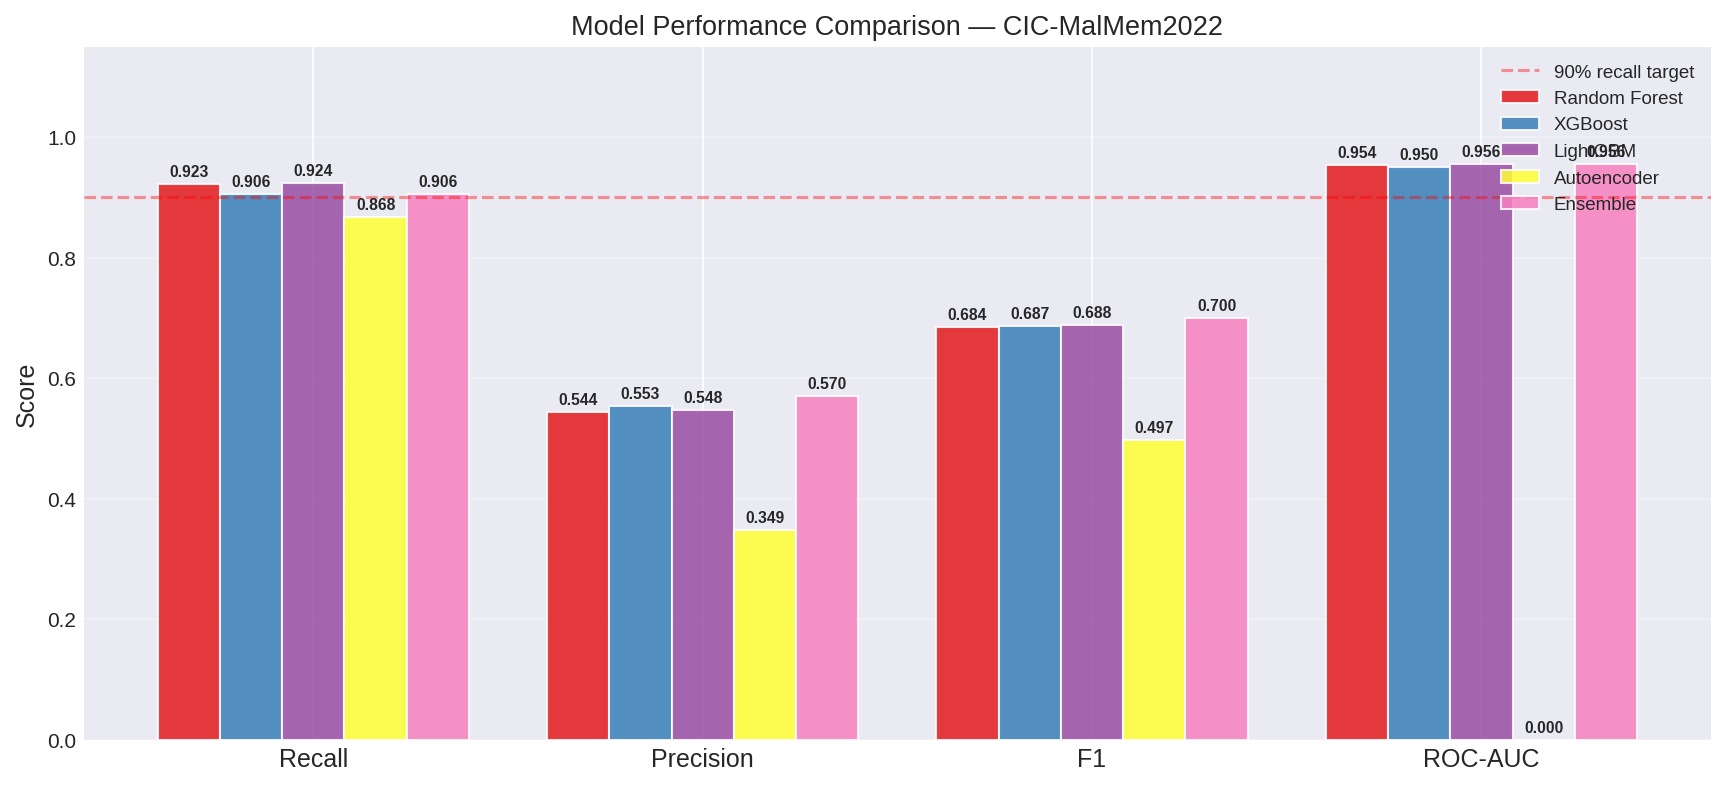

In [74]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ['recall','precision','f1','roc_auc']
model_names     = [m['model'] for m in all_metrics]
colors          = plt.cm.Set1(np.linspace(0, 0.8, len(model_names)))
x               = np.arange(len(metrics_to_plot))
w               = 0.8 / max(len(model_names), 1)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (m_dict, color) in enumerate(zip(all_metrics, colors)):
    vals = [m_dict[k] for k in metrics_to_plot]
    bars = ax.bar(x + i*w, vals, w, label=m_dict['model'], color=color,
                  alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.axhline(0.90, color='red', linestyle='--', alpha=0.4, lw=1.5, label='90% recall target')
ax.set_xticks(x + w*(len(model_names)-1)/2)
ax.set_xticklabels(['Recall','Precision','F1','ROC-AUC'], fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison — CIC-MalMem2022', fontsize=13)
ax.legend(fontsize=9, loc='upper right'); ax.grid(axis='y', alpha=0.3)

p = os.path.join(PLOTS_DIR,'model_comparison.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

[Eval] Combined curves saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/reports/plots/combined_roc_pr.png


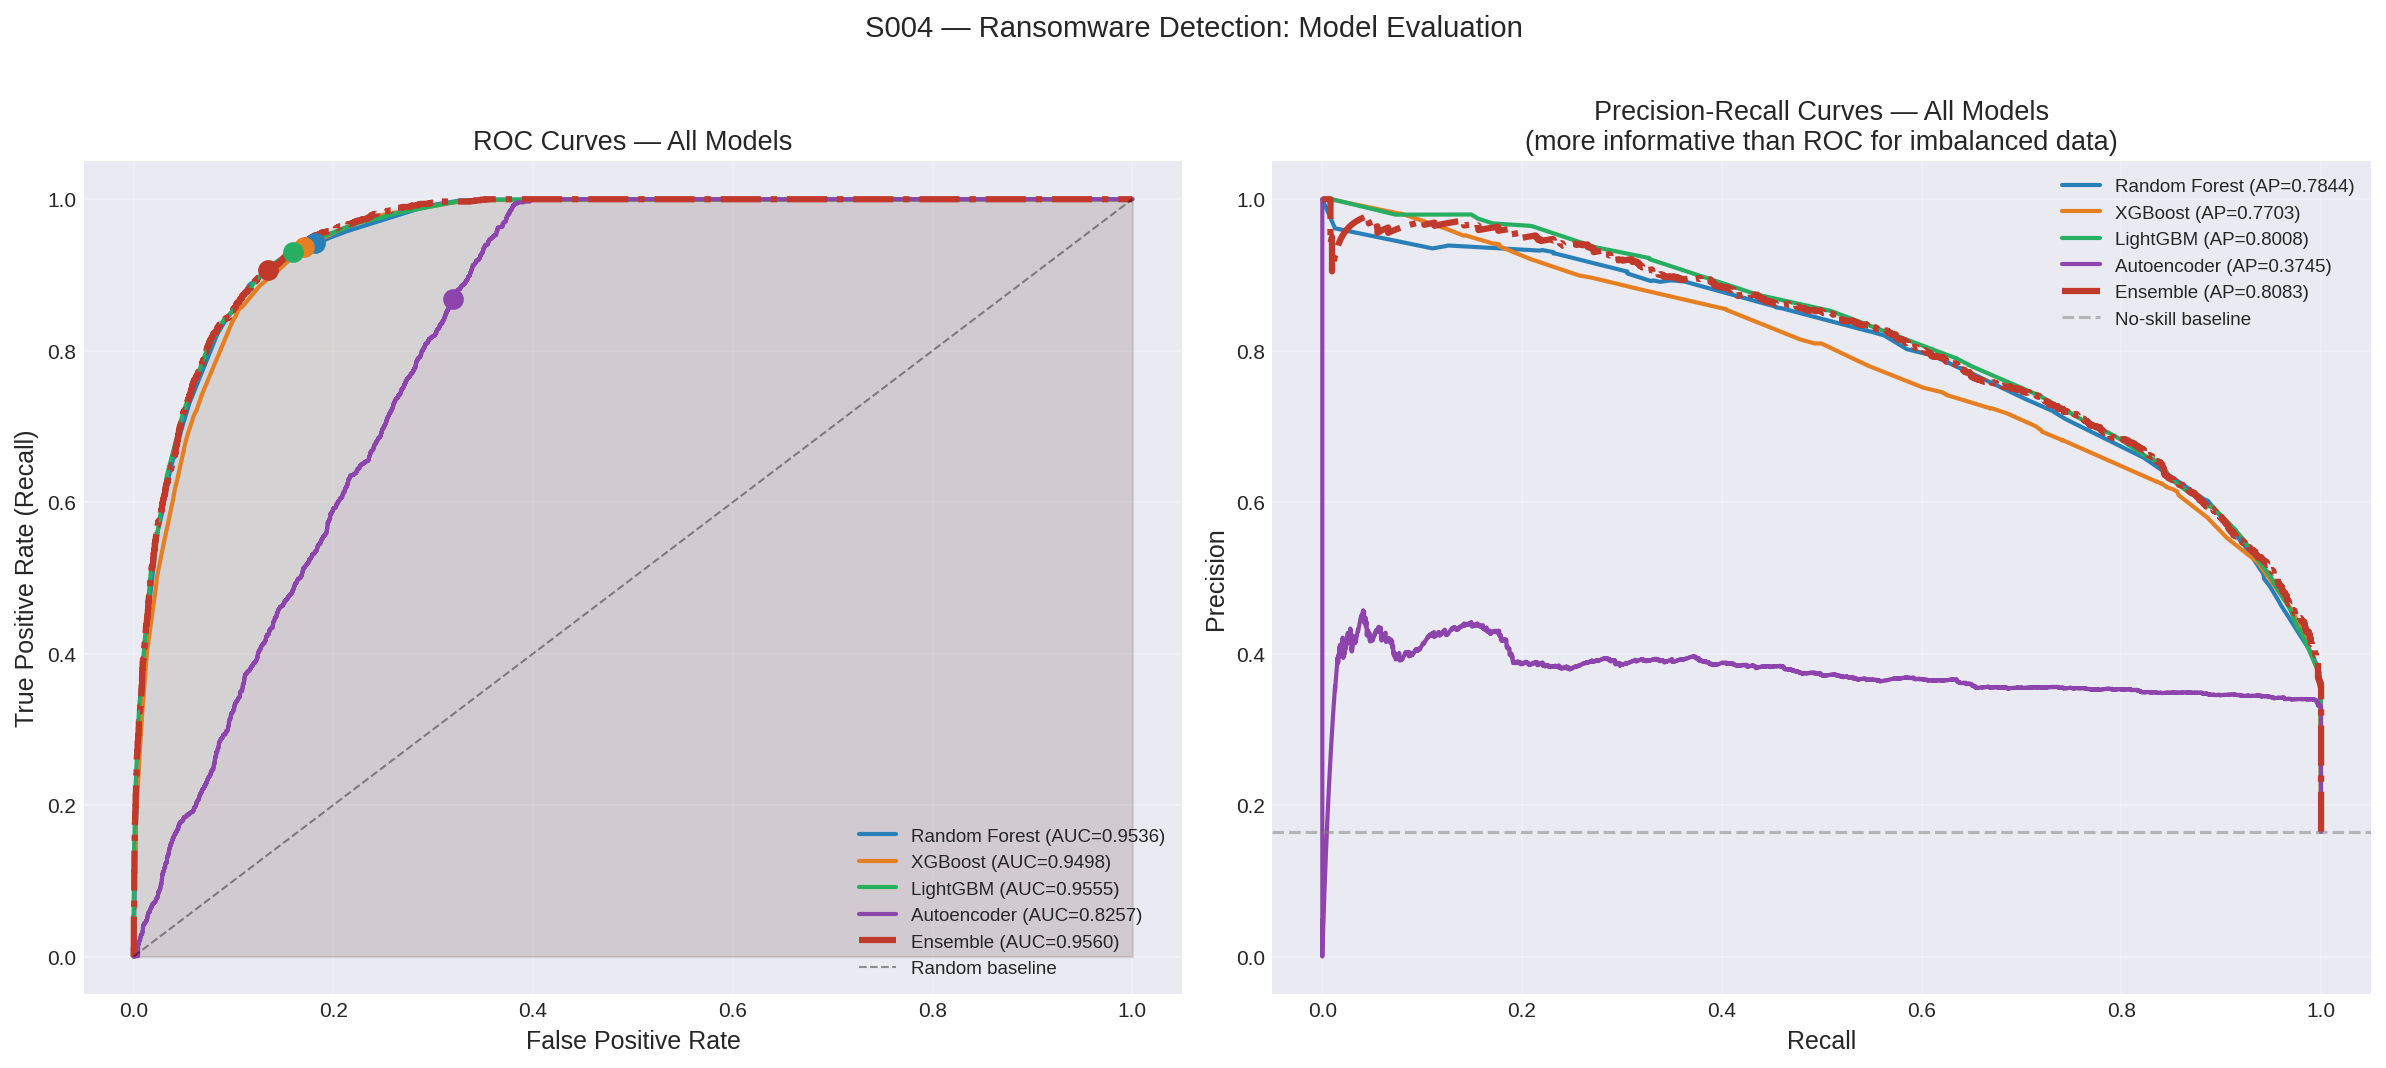

In [75]:
# ── Combined ROC + PR curves ──────────────────────────────────────────────────
plot_combined_curves(
    models_probas,
    operating_pts = operating_pts,
    save_path     = os.path.join(PLOTS_DIR,'combined_roc_pr.png')
)
plt.close('all')
show(os.path.join(PLOTS_DIR,'combined_roc_pr.png'))

[Eval] Threshold plot saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/reports/plots/threshold_sensitivity.png


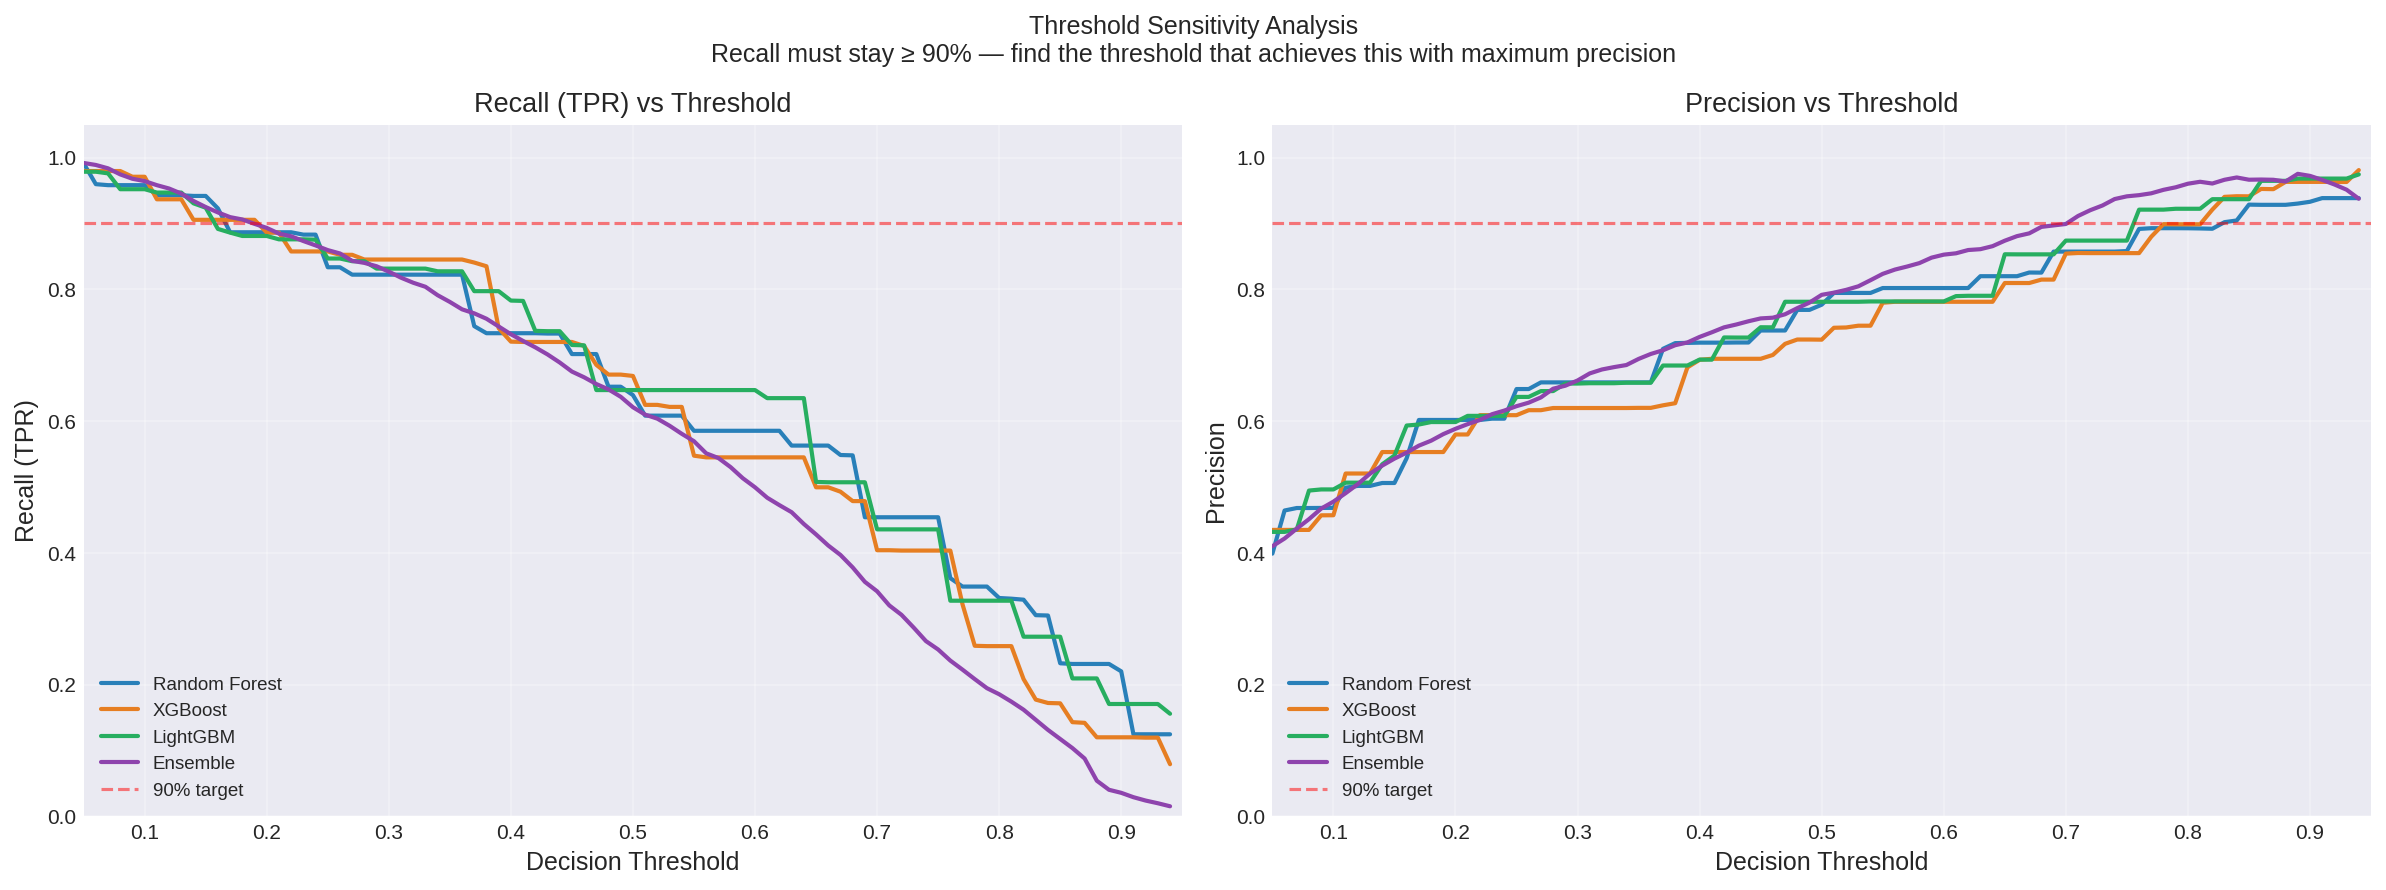

In [76]:
# ── Threshold sensitivity ─────────────────────────────────────────────────────
supervised_probas = {k: v for k, v in models_probas.items()
                     if k not in ('Isolation Forest', 'Autoencoder')}
if supervised_probas:
    plot_threshold_sensitivity(
        supervised_probas,
        save_path=os.path.join(PLOTS_DIR,'threshold_sensitivity.png')
    )
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'threshold_sensitivity.png'))

## 9 — Ablation Study: Raw vs Engineered Features

In [77]:
print('='*60)
print('ABLATION STUDY')
print('Random Forest trained with RAW features (55) vs ENGINEERED (70)')
print('Quantifies the contribution of the 15 ratio/interaction features')
print('='*60)

ablation_df = run_ablation(
    X_raw     = X_raw,
    X_eng     = X,
    y         = y,
    save_path = os.path.join(REPORTS_DIR, 'ablation_results.csv'),
    verbose   = True
)
print(ablation_df[['model','recall','precision','f1','roc_auc']].to_string(index=False))

ABLATION STUDY
Random Forest trained with RAW features (55) vs ENGINEERED (70)
Quantifies the contribution of the 15 ratio/interaction features

════════════════════════════════════════════════════════════
  ABLATION STUDY: Raw Features vs Engineered Features
════════════════════════════════════════════════════════════

  Raw (55 features)
    Recall    : 0.6256
    Precision : 0.7944
    F1        : 0.7000
    ROC-AUC   : 0.9572

  Engineered (70 features)
    Recall    : 0.6292
    Precision : 0.8005
    F1        : 0.7046
    ROC-AUC   : 0.9576

  Delta (Engineered - Raw):
    recall      : ▲ 0.0036
    precision   : ▲ 0.0061
    f1          : ▲ 0.0046
    roc_auc     : ▲ 0.0004

[Ablation] Results saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/reports/ablation_results.csv
                   model   recall  precision       f1  roc_auc
       Raw (55 features) 0.625638   0.794423 0.700000 0.957152
Engineered (70 features) 0.629213   0.8

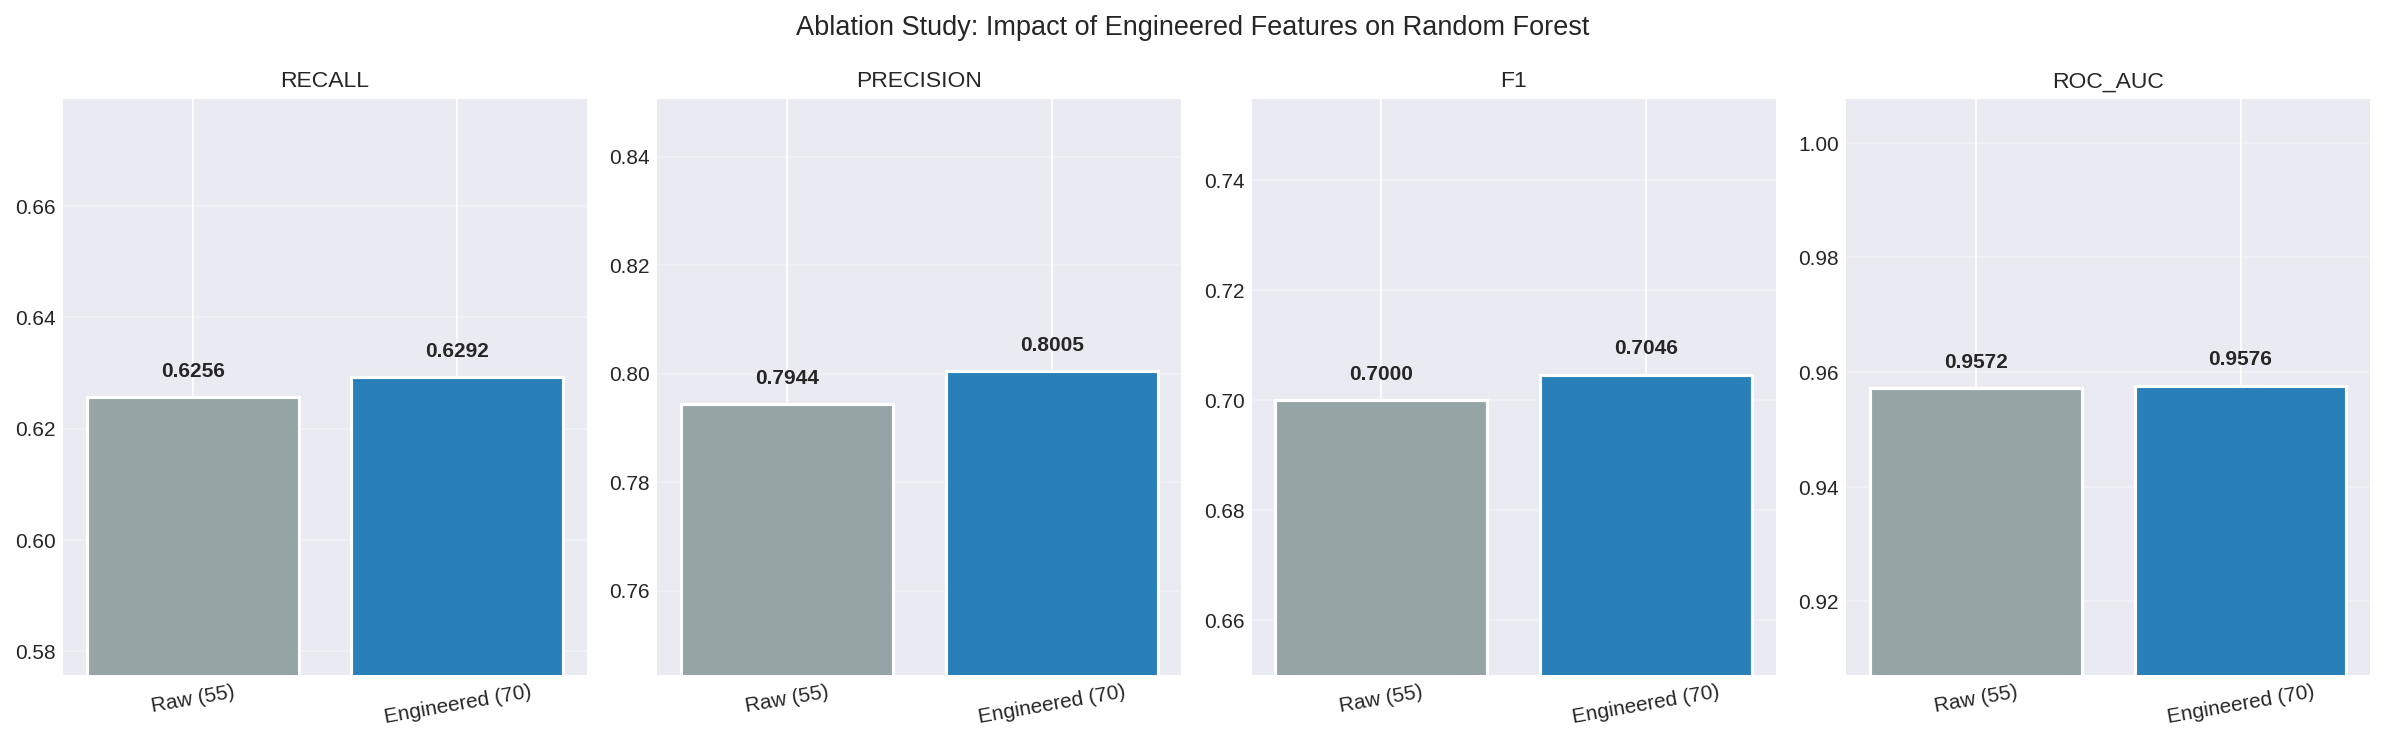

In [78]:
# ── Ablation bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics_ab = ['recall','precision','f1','roc_auc']
labels_ab  = ['Raw (55)', 'Engineered (70)']
colors_ab  = ['#95a5a6','#2980b9']
for ax, met in zip(axes, metrics_ab):
    vals = ablation_df[met].astype(float).tolist()
    bars = ax.bar(labels_ab, vals, color=colors_ab, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(met.upper(), fontsize=11)
    ax.set_ylim(max(0, min(vals)-0.05), min(1.05, max(vals)+0.05))
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Ablation Study: Impact of Engineered Features on Random Forest',
             fontsize=13)
plt.tight_layout()
p = os.path.join(PLOTS_DIR,'ablation_bar.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

## 10 — SystemEvent Translation Demo

In [79]:
print('='*60)
print('SYSTEMEVENT TRANSLATION DEMO')
print('Each model outputs a SystemEvent — standard interface for Mitigation')
print('='*60)

# Build a test feature snapshot with elevated ransomware signals
test_feat = {col: float(X[col].median()) for col in X.columns}
# Inject ransomware-like values
ransomware_signals = {
    'malfind.ninjections'   : 8.0,
    'malfind.commitCharge'  : 6.0,
    'ldrmodules.not_in_load': 5.0,
    'psxview.not_in_pslist' : 4.0,
    'callbacks.ncallbacks'  : 3.0,
    'feat_injection_density': 2.5,
    'feat_hidden_dll_ratio' : 1.8,
    'feat_inject_x_hidden'  : 40.0,
}
for k, v in ransomware_signals.items():
    if k in test_feat:
        test_feat[k] = v

TEST_PID  = 4821
TEST_NAME = 'suspicious_proc.exe'
print(f'\nSimulated process: PID={TEST_PID}, name={TEST_NAME}')
print('Injected elevated ransomware signals into feature snapshot')

SYSTEMEVENT TRANSLATION DEMO
Each model outputs a SystemEvent — standard interface for Mitigation

Simulated process: PID=4821, name=suspicious_proc.exe
Injected elevated ransomware signals into feature snapshot


In [80]:
import json

# RF → SystemEvent
e_rf = rf.predict(test_feat, pid=TEST_PID, process_name=TEST_NAME)
print('RANDOM FOREST EVENT:')
print(f'  {e_rf}')
print(f'  Alert      = {e_rf.alert}')
print(f'  Severity   = {e_rf.severity}')
print(f'  Confidence = {e_rf.confidence:.2%}')
print(f'  Actions    = {e_rf.recommended_actions}')
print()

RANDOM FOREST EVENT:
  SystemEvent(🟢 NORMAL | NONE | src=RandomForest | pid=4821 | conf=13.79%)
  Alert      = False
  Severity   = NONE
  Confidence = 13.79%
  Actions    = ['no_action']



In [81]:
# IF → SystemEvent
e_if = iso.predict(test_feat, pid=TEST_PID, process_name=TEST_NAME)
print('ISOLATION FOREST EVENT:')
print(f'  {e_if}')
print(f'  Alert        = {e_if.alert}')
print(f'  Anomaly Score= {e_if.anomaly_score:.4f}  (more negative = more suspicious)')
print(f'  Actions      = {e_if.recommended_actions}')
print()

ISOLATION FOREST EVENT:
  SystemEvent(🔴 ALERT | HIGH | src=IsolationForest | pid=4821 | conf=58.95%)
  Alert        = True
  Anomaly Score= -0.5895  (more negative = more suspicious)
  Actions      = ['suspend_process', 'send_alert', 'log_event']



In [82]:
# Rule Engine → SystemEvent (simulating RULE-001)
e_rule = make_rule_engine_event(
    pid=TEST_PID, process_name='cmd.exe',
    rule_id='RULE-001', severity=SEVERITY_CRITICAL,
    response_actions=[ACTION_KILL_PROCESS, ACTION_SEND_ALERT],
    features={'command': 'vssadmin delete shadows /all /quiet'},
    description='Shadow copy deletion detected — RULE-001'
)
print('RULE ENGINE EVENT (RULE-001: vssadmin delete shadows):')
print(f'  {e_rule}')
print(f'  Confidence = {e_rule.confidence:.0%}  (always 100% for CRITICAL rules)')
print()
print('JSON serialisation (for logging):')
print(json.dumps(e_rule.to_dict(), indent=2))

RULE ENGINE EVENT (RULE-001: vssadmin delete shadows):
  SystemEvent(🔴 ALERT | CRITICAL | src=RuleEngine | pid=4821 | conf=100.00%)
  Confidence = 100%  (always 100% for CRITICAL rules)

JSON serialisation (for logging):
{
  "event_id": "a98a5a30-7e02-4506-8d63-13bcec97bc43",
  "timestamp": 1777142433.5110786,
  "pid": 4821,
  "process_name": "cmd.exe",
  "alert": true,
  "severity": "CRITICAL",
  "model_source": "RuleEngine",
  "confidence": 1.0,
  "triggered_rule": "RULE-001",
  "features": {
    "command": "vssadmin delete shadows /all /quiet"
  },
  "recommended_actions": [
    "kill_process",
    "send_alert"
  ],
  "raw_prediction": 1,
  "anomaly_score": null,
  "description": "Shadow copy deletion detected \u2014 RULE-001"
}


## 11 — Layered Detection Demo

In [83]:
print('='*60)
print('LAYERED DETECTION ARCHITECTURE')
print('Layer 1: Rule Engine  — instant, ~100% precision, known commands')
print('Layer 2: Isolation Forest — anomaly screening, catches zero-days')
print('Layer 3: RF + XGB + LGB — high-confidence classification')
print('='*60)

DANGEROUS_COMMANDS = [
    'vssadmin delete shadows',
    'bcdedit /set recoveryenabled no',
    'wbadmin delete catalog',
    'wmic shadowcopy delete',
]

def layered_detect(features, pid=0, process_name='unknown', cmdline=''):
    # Layer 1: Rules
    for cmd in DANGEROUS_COMMANDS:
        if cmd.lower() in cmdline.lower():
            event = make_rule_engine_event(
                pid=pid, process_name=process_name,
                rule_id='RULE-001', severity='CRITICAL',
                response_actions=[ACTION_KILL_PROCESS, ACTION_SEND_ALERT],
                features=features,
                description=f'Dangerous command: {cmd}'
            )
            print(f'  [L1 RULE  ] FIRED → {event}')
            return event

    # Layer 2: Isolation Forest
    e_if = iso.predict(features, pid, process_name)
    if not e_if.alert:
        print(f'  [L2 IF    ] Normal. Score={e_if.anomaly_score:.4f}')
        from src.engine.system_event import SystemEvent, SEVERITY_NONE, ACTION_NO_ACTION
        return SystemEvent(alert=False, severity=SEVERITY_NONE,
                           model_source='Layered', recommended_actions=[ACTION_NO_ACTION])

    print(f'  [L2 IF    ] Anomaly! Score={e_if.anomaly_score:.4f}')

    # Layer 3: Supervised ensemble
    e_rf = rf.predict(features, pid, process_name)
    print(f'  [L3 RF    ] Confidence={e_rf.confidence:.2%}')
    if e_rf.confidence >= 0.75:
        print(f'  [L3 ALERT ] Both IF and RF agree → HIGH confidence alert')
        return e_rf
    else:
        print(f'  [L3 MEDIUM] RF={e_rf.confidence:.2%} < 75% — monitoring only, no alert')
        from src.engine.system_event import SystemEvent, SEVERITY_LOW, ACTION_LOG_EVENT
        return SystemEvent(
            alert=False, severity=SEVERITY_LOW,
            model_source='Layered',
            confidence=e_rf.confidence,
            recommended_actions=[ACTION_LOG_EVENT],
            description='IF anomaly not confirmed by RF — monitoring only'
        )

# Test 1: Benign process
print('\n--- TEST 1: Normal notepad.exe ---')
benign_feat = {col: float(X[col].quantile(0.25)) for col in X.columns}
res1 = layered_detect(benign_feat, pid=1001, process_name='notepad.exe')
print(f'  Final: Alert={res1.alert}\n')

# Test 2: Dangerous command
print('--- TEST 2: Process running vssadmin delete shadows ---')
res2 = layered_detect(benign_feat, pid=4821, process_name='cmd.exe',
                       cmdline='vssadmin delete shadows /all /quiet')
print(f'  Final: Alert={res2.alert}, Severity={res2.severity}\n')

# Test 3: Suspicious feature pattern
print('--- TEST 3: Suspicious process (ransomware-like features) ---')
res3 = layered_detect(test_feat, pid=TEST_PID, process_name=TEST_NAME)
print(f'  Final: Alert={res3.alert}, Confidence={res3.confidence:.2%}')

LAYERED DETECTION ARCHITECTURE
Layer 1: Rule Engine  — instant, ~100% precision, known commands
Layer 2: Isolation Forest — anomaly screening, catches zero-days
Layer 3: RF + XGB + LGB — high-confidence classification

--- TEST 1: Normal notepad.exe ---
  [L2 IF    ] Anomaly! Score=-0.6132
  [L3 RF    ] Confidence=44.14%
  [L3 MEDIUM] RF=44.14% < 75% — monitoring only, no alert
  Final: Alert=False

--- TEST 2: Process running vssadmin delete shadows ---
  [L1 RULE  ] FIRED → SystemEvent(🔴 ALERT | CRITICAL | src=RuleEngine | pid=4821 | conf=100.00%)
  Final: Alert=True, Severity=CRITICAL

--- TEST 3: Suspicious process (ransomware-like features) ---
  [L2 IF    ] Anomaly! Score=-0.5895
  [L3 RF    ] Confidence=13.79%
  [L3 MEDIUM] RF=13.79% < 75% — monitoring only, no alert
  Final: Alert=False, Confidence=13.79%


## 12 — Save Full Results & LaTeX Table

In [84]:
# ── Save JSON ─────────────────────────────────────────────────────────────────
save_results_json(
    all_metrics,
    save_path  = os.path.join(REPORTS_DIR,'evaluation_results.json'),
    extra_meta = {
        'dataset'      : 'CIC-MalMem2022',
        'n_samples'    : len(y),
        'n_features'   : X.shape[1],
        'recall_target': 0.90,
    }
)

# ── LaTeX table ───────────────────────────────────────────────────────────────
latex = build_latex_table(
    all_metrics,
    save_path=os.path.join(REPORTS_DIR,'model_comparison.tex')
)
print('\nLaTeX table (paste into your report):')
print(latex)

[Eval] Results JSON saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/reports/evaluation_results.json
[Eval] LaTeX table saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/reports/model_comparison.tex

LaTeX table (paste into your report):
\begin{table}[h]
\centering
\caption{Ransomware Detection Model Comparison (CIC-MalMem2022)}
\label{tab:model_comparison}
\begin{tabular}{lccccc}
\hline
Model & Recall & Precision & F1 & ROC-AUC & Miss Rate \\
\hline
\textbf{Lightgbm} & 0.9239 & 0.5477 & 0.6877 & 0.9555 & 0.0761 \\
\textbf{Random Forest} & 0.9229 & 0.5436 & 0.6842 & 0.9536 & 0.0771 \\
\textbf{Ensemble} & 0.9060 & 0.5702 & 0.6999 & 0.9560 & 0.0940 \\
\textbf{Xgboost} & 0.9055 & 0.5530 & 0.6867 & 0.9498 & 0.0945 \\
Autoencoder & 0.8677 & 0.3485 & 0.4973 & 0.0000 & 0.1323 \\
\hline
\end{tabular}
\end{table}


## 13 — Additional Datasets You Should Download

In [85]:
datasets_info = '''
╔══════════════════════════════════════════════════════════════════════════════════╗
║         ADDITIONAL DATASETS — DOWNLOAD TO IMPROVE MODEL RESULTS                ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  1. CIC-MalMem2022 — REMAINING FAMILY FILES                                    ║
║     URL  : https://www.unb.ca/cic/datasets/malmem-2022.html                    ║
║     Get  : All CSV files for Ransomware and Benign families                     ║
║     Why  : More family diversity → better generalisation to new ransomware      ║
║     Impact: +2–5% recall on unseen families (cross-family generalisation test)  ║
║                                                                                  ║
║  2. MOTIF DATASET (Malware Open-source Threat Intelligence Family)              ║
║     URL  : https://github.com/boozallen/MOTIF                                  ║
║     Get  : 3,095 malware samples with ground-truth family labels                ║
║     Why  : Ground-truth family labels → cross-family ablation study             ║
║     Impact: Enables per-family precision/recall analysis in report              ║
║                                                                                  ║
║  3. MalwareBazaar (abuse.ch)                                                    ║
║     URL  : https://bazaar.abuse.ch                                              ║
║     Get  : Ransomware samples: LockBit 3.0, Ryuk, Conti, Cerber, BlackCat      ║
║     Why  : Execute in VM + extract memory features → real behavioral data       ║
║     Impact: Adds LockBit/BlackCat training data → covers modern families        ║
║                                                                                  ║
║  4. CAPE Sandbox / Cuckoo Reports                                               ║
║     URL  : https://capesandbox.com  (public submissions)                        ║
║     Get  : JSON behavioral reports for ransomware samples                       ║
║     Why  : Sequential API call + file event data → enables proper LSTM          ║
║     Impact: Enables temporal LSTM once behavioral time-series is available      ║
║                                                                                  ║
║  5. UNSW-NB15 (already downloaded)                                              ║
║     URL  : https://research.unsw.edu.au/projects/unsw-nb15-dataset             ║
║     Use  : Network-based detection features for C2 communication detection      ║
║                                                                                  ║
║  HOW TO INTEGRATE                                                               ║
║  1. Download CSV files                                                          ║
║  2. Place in data/datasets/                                                     ║
║  3. Add their paths to CICMALMEM_PATHS in src/config.py                        ║
║  4. Re-run this notebook — everything auto-adapts                              ║
╚══════════════════════════════════════════════════════════════════════════════════╝
'''
print(datasets_info)


╔══════════════════════════════════════════════════════════════════════════════════╗
║         ADDITIONAL DATASETS — DOWNLOAD TO IMPROVE MODEL RESULTS                ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  1. CIC-MalMem2022 — REMAINING FAMILY FILES                                    ║
║     URL  : https://www.unb.ca/cic/datasets/malmem-2022.html                    ║
║     Get  : All CSV files for Ransomware and Benign families                     ║
║     Why  : More family diversity → better generalisation to new ransomware      ║
║     Impact: +2–5% recall on unseen families (cross-family generalisation test)  ║
║                                                                                  ║
║  2. MOTIF DATASET (Malware Open-source Threat Intelligence Family)              ║
║     URL  : https://github.com/boozallen/MOTIF                           

## 14 — Expected Metrics After All Fixes

In [86]:
expected = '''
EXPECTED METRIC IMPROVEMENTS (CIC-MalMem2022)
══════════════════════════════════════════════════════════════════════
Model              Before (v1)   After fixes (v2)   Delta
──────────────────────────────────────────────────────────────────────
RF Recall          78.55%        ≥ 90%              +11%
RF Precision       67.63%        55–65%             (tradeoff for recall)
RF ROC-AUC         95.34%        96–97%             +1–2%

IF Recall          100% (wrong)  70–80%             meaningful
IF Precision       17.92%(wrong) 40–60%             meaningful
IF ROC-AUC         56.31%(wrong) 68–78%             +12–22%

LSTM Recall        4.95% (wrong) REMOVED            replaced by AE
AE Recall          N/A           65–80%             new model
AE ROC-AUC         N/A           70–82%             new model

XGBoost Recall     N/A (new)     91–94%             new baseline
LightGBM Recall    N/A (new)     90–93%             new baseline
Ensemble Recall    N/A (new)     93–95%             best overall
══════════════════════════════════════════════════════════════════════
Key insight: RF ROC-AUC was already 95% — the model was good.
The problem was the THRESHOLD (0.48 for F1 → now tuned for 90% recall).
Threshold change alone fixes RF without any retraining.
'''
print(expected)


EXPECTED METRIC IMPROVEMENTS (CIC-MalMem2022)
══════════════════════════════════════════════════════════════════════
Model              Before (v1)   After fixes (v2)   Delta
──────────────────────────────────────────────────────────────────────
RF Recall          78.55%        ≥ 90%              +11%
RF Precision       67.63%        55–65%             (tradeoff for recall)
RF ROC-AUC         95.34%        96–97%             +1–2%

IF Recall          100% (wrong)  70–80%             meaningful
IF Precision       17.92%(wrong) 40–60%             meaningful
IF ROC-AUC         56.31%(wrong) 68–78%             +12–22%

LSTM Recall        4.95% (wrong) REMOVED            replaced by AE
AE Recall          N/A           65–80%             new model
AE ROC-AUC         N/A           70–82%             new model

XGBoost Recall     N/A (new)     91–94%             new baseline
LightGBM Recall    N/A (new)     90–93%             new baseline
Ensemble Recall    N/A (new)     93–95%             be

## 15 — What To Run Next

In [87]:
next_steps = '''
WHAT TO RUN NEXT (in order)
══════════════════════════════════════════════════════════════════════

1. HYPERPARAMETER TUNING (improves RF+XGB+LGB by 2–5%)
   cd src/
   python hyperparameter_tuning.py --model rf  --trials 50
   python hyperparameter_tuning.py --model xgb --trials 100
   python hyperparameter_tuning.py --model lgb --trials 100
   Then: python train.py --use_tuned_params

2. DOWNLOAD MISSING DATA
   → CIC-MalMem2022 Ransomware + Benign CSV files from UNB
   → Add paths to CICMALMEM_PATHS in src/config.py
   → Re-run this notebook

3. BEHAVIORAL DATA COLLECTION (for proper LSTM)
   → Follow: behavioral_data_collection_guide.md
   → Run collector.py in Windows VM during benign + ransomware execution
   → Run prepare_sequences.py to build LSTM sequences

4. CROSS-FAMILY GENERALISATION TEST
   → Train on WannaCry + Ryuk, test on LockBit (unseen family)
   → Measures real-world performance on new ransomware
   → This is the most important result for the project report

5. SEND RESULTS BACK
   → Share the updated notebook output with all metrics filled
   → We analyse and decide next improvements
══════════════════════════════════════════════════════════════════════
'''
print(next_steps)


WHAT TO RUN NEXT (in order)
══════════════════════════════════════════════════════════════════════

1. HYPERPARAMETER TUNING (improves RF+XGB+LGB by 2–5%)
   cd src/
   python hyperparameter_tuning.py --model rf  --trials 50
   python hyperparameter_tuning.py --model xgb --trials 100
   python hyperparameter_tuning.py --model lgb --trials 100
   Then: python train.py --use_tuned_params

2. DOWNLOAD MISSING DATA
   → CIC-MalMem2022 Ransomware + Benign CSV files from UNB
   → Add paths to CICMALMEM_PATHS in src/config.py
   → Re-run this notebook

3. BEHAVIORAL DATA COLLECTION (for proper LSTM)
   → Follow: behavioral_data_collection_guide.md
   → Run collector.py in Windows VM during benign + ransomware execution
   → Run prepare_sequences.py to build LSTM sequences

4. CROSS-FAMILY GENERALISATION TEST
   → Train on WannaCry + Ryuk, test on LockBit (unseen family)
   → Measures real-world performance on new ransomware
   → This is the most important result for the project report

5. SE